In [ ]:
# ============================================================
# RUN THIS ONCE AFTER EVERY RUNTIME REFRESH
# ============================================================

import os
import shutil
import zipfile
import glob

# Your exact Google Drive path
DRIVE_PATH = "G:/My Drive"

# Create project folder locally (in the same directory as this notebook)
PROJECT_DIR = "./content/project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# Copy any saved model checkpoints (.pth) from Drive
for file in glob.glob(f"{DRIVE_PATH}/msc project/*.pth"):
    print(f"Copying {os.path.basename(file)}...")
    shutil.copy(file, PROJECT_DIR)

# Extract dataset if needed
data_dir = os.path.join(PROJECT_DIR, "data")
if not os.path.exists(data_dir):
    zip_path = f"{DRIVE_PATH}/msc project/zipped file project/data.zip"
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(PROJECT_DIR)

# Switch into project directory
os.chdir(PROJECT_DIR)

print("Current directory:", os.getcwd())
print(f"Patients found: {len(glob.glob('./data/training/patient*'))}")
print("Setup complete.")


Copying unet_best.pth...
Copying attention_unet_best.pth...
Copying transunet_best.pth...
Copying unet_best_v2.pth...
Copying attention_unet_best_v2.pth...
Copying unet_dacl_best.pth...
Copying transunet_best_v2.pth...
Copying transunet_head_checkpoint.pth...
Copying unet_dacl.pth...
Extracting G:/My Drive/msc project/zipped file project/data.zip...
Current directory: c:\Users\patha\Downloads\Hamna's Project\content\project
Patients found: 100
Setup complete.


In [ ]:
pip install PyDrive2

   ---------------------------------------- 0.0/3.1 MB ? eta -:--:--
   --------------------------- ------------ 2.1/3.1 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 3.1/3.1 MB 16.3 MB/s  0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   --------------------- ------------------ 8.4/15.6 MB 40.0 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.6 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------- 15.6/15.6 MB 35.2 MB/s  0:00:00

   ----------------------------------------  0/16 [uritemplate]
  Attempting uninstall: requests
   ----------------------------------------  0/16 [uritemplate]
    Found existing installation: requests 2.32.5
   ----------------------------------------  0/16 [uritemplate]
   -- -------------------------------------  1/16 [requests]
    Uninstalling requests-2.32.5:
   -- -------------------------------------  1/16 [requests]
      Successfully uninstalled requests-2.32.5

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
pyhanko 0.35.1 requires cryptography>=48.0.0, but you have cryptography 43.0.3 which is incompatible.
pyhanko-certvalidator 0.31.1 requires cryptography>=48.0.0, but you have cryptography 43.0.3 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil, os
shutil.copytree("/content/drive/MyDrive/msc project/zipped file project", "/content/project")
os.chdir("/content/project")
!ls

data.zip


In [ ]:
!pip install nibabel tqdm
!python train_segmentation.py

python3: can't open file '/content/project/train_segmentation.py': [Errno 2] No such file or directory


In [ ]:
import os
os.chdir("/content/project")
!ls

In [ ]:
import os
print(os.path.exists("unet_best.pth"))  # should print True

False


In [ ]:
import shutil, os
shutil.copy("/content/drive/MyDrive/msc project/unet_best.pth", "/content/project/unet_best.pth")
print(os.path.exists("/content/project/unet_best.pth"))

True


In [ ]:
!ls /content/project

unet_best.pth


In [ ]:
import zipfile
with zipfile.ZipFile("/content/project/data.zip", 'r') as z:
    z.extractall("/content/project")
!ls

data	    data.zip	    train_segmentation.py  unet.py
dataset.py  test_loader.py  unet_best.pth	   visualize_predictions.py


In [ ]:
import pandas as pd

print("===== IMAGE PREDICTIONS METRICS =====")
img_df = pd.read_csv("/content/drive/MyDrive/msc project/test_results.csv")
print(img_df[["RV_Dice","Myo_Dice","LV_Dice","Mean_Dice"]].mean().round(4))

print("\n===== VIDEO PREDICTIONS METRICS =====")
vid_df = pd.read_csv("/content/drive/MyDrive/msc project/video_metrics.csv")
print(vid_df[["ED_RV_Dice","ED_Myo_Dice","ED_LV_Dice",
              "ES_RV_Dice","ES_Myo_Dice","ES_LV_Dice","Mean_Dice"]].mean().round(4))


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, 1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, 1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.pool = nn.MaxPool2d(2)

        # Attention gates
        self.att4 = AttentionGate(1024, 512, 256)
        self.att3 = AttentionGate(512, 256, 128)
        self.att2 = AttentionGate(256, 128, 64)
        self.att1 = AttentionGate(128, 64, 32)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        # Decoder with attention
        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

In [ ]:
import os
os.chdir("/content/project")
!ls

unet_best.pth


In [ ]:
import os
# Search for dataset.py in Drive
for root, dirs, files in os.walk("/content/drive/MyDrive/msc project"):
    for file in files:
        print(os.path.join(root, file))

/content/drive/MyDrive/msc project/unet_best.pth
/content/drive/MyDrive/msc project/predictions.png
/content/drive/MyDrive/msc project/all_patients_results.csv
/content/drive/MyDrive/msc project/test_predictions.zip
/content/drive/MyDrive/msc project/test_results.csv
/content/drive/MyDrive/msc project/confusion_matrix.png
/content/drive/MyDrive/msc project/test_videos.zip
/content/drive/MyDrive/msc project/video_metrics.csv
/content/drive/MyDrive/msc project/video_metrics_bar.png
/content/drive/MyDrive/msc project/video_confusion_matrix.png


In [ ]:
from google.colab import files
uploaded = files.upload()
# Select these files from your PC:
# dataset.py, unet.py, train_segmentation.py, test_loader.py, visualize_predictions.py

In [ ]:
!ls /content

drive  project	sample_data


In [ ]:
import os
os.chdir("/content/project")

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/content/project'

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from attention_unet import AttentionUNet
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = ACDCDataset("data")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

model = AttentionUNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def dice_score(pred, target, num_classes=4):
    dice = 0.0
    pred = torch.argmax(pred, dim=1)
    for cls in range(1, num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += (2.0 * intersection + 1e-8) / (union + 1e-8)
    return dice / (num_classes - 1)

epochs = 30
best_dice = 0.0

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0.0

    for imgs, masks, _ in tqdm(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_dice += dice_score(outputs, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)

    print(f"Epoch {epoch+1} | Loss: {avg_train_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        torch.save(model.state_dict(), "attention_unet_best.pth")
        print("Best model saved!")

print(f"\nTraining finished. Best Dice: {best_dice:.4f}")

ModuleNotFoundError: No module named 'attention_unet'

In [ ]:
import os
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "data" in file.lower():
            print(os.path.join(root, file))

/content/drive/MyDrive/Colab Notebooks/ASA Datafest.ipynb
/content/drive/MyDrive/COMP5625M_Summative Assessment_2026/__MACOSX/._Flicker8k_Dataset


In [ ]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
    z.extractall("/content/project")
print("Done!")
!ls /content/project

Done!
data	    __pycache__     train_segmentation.py  unet.py
dataset.py  test_loader.py  unet_best.pth	   visualize_predictions.py


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm

# ---- Attention U-Net Definition ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        return x * self.psi(psi)

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024)
        self.pool = nn.MaxPool2d(2)

        self.att4 = AttentionGate(512, 512, 256)
        self.att3 = AttentionGate(256, 256, 128)
        self.att2 = AttentionGate(128, 128, 64)
        self.att1 = AttentionGate(64, 64, 32)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

# ---- Training ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = ACDCDataset("data")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

model = AttentionUNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def dice_score(pred, target, num_classes=4):
    dice = 0.0
    pred = torch.argmax(pred, dim=1)
    for cls in range(1, num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += (2.0 * intersection + 1e-8) / (union + 1e-8)
    return dice / (num_classes - 1)

epochs = 30
best_dice = 0.0

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0.0
    for imgs, masks, _ in tqdm(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_dice += dice_score(outputs, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {avg_train_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        torch.save(model.state_dict(), "attention_unet_best.pth")
        print("Best model saved!")

print(f"\nTraining finished. Best Dice: {best_dice:.4f}")

Using device: cuda

Starting Epoch 1/30


100%|██████████| 381/381 [01:50<00:00,  3.43it/s]


Epoch 1 | Loss: 0.1537 | Val Dice: 0.5421
Best model saved!

Starting Epoch 2/30


100%|██████████| 381/381 [01:55<00:00,  3.29it/s]


Epoch 2 | Loss: 0.0517 | Val Dice: 0.6377
Best model saved!

Starting Epoch 3/30


...

Epoch 28 | Loss: 0.0092 | Val Dice: 0.9101

Starting Epoch 29/30


100%|██████████| 381/381 [01:55<00:00,  3.29it/s]


Epoch 29 | Loss: 0.0088 | Val Dice: 0.9102

Starting Epoch 30/30


100%|██████████| 381/381 [01:56<00:00,  3.28it/s]


Epoch 30 | Loss: 0.0076 | Val Dice: 0.9136
Best model saved!

Training finished. Best Dice: 0.9136


In [ ]:
import shutil
shutil.copy("attention_unet_best.pth", "/content/drive/MyDrive/msc project/attention_unet_best.pth")
print("Saved!")

Saved!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm

# ---- Patch Embedding ----
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1, stride=1)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x, H, W

# ---- Transformer Block ----
class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn = nn.MultiheadAttention(emb_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim * mlp_ratio, emb_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

# ---- Conv Block ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

# ---- TransUNet ----
class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()

        # CNN Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)
        self.enc4 = ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Transformer
        self.patch_embed = PatchEmbedding(in_ch=512, emb_dim=emb_dim)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(emb_dim=emb_dim, num_heads=num_heads)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(emb_dim)
        self.proj_back = nn.Conv2d(emb_dim, 512, kernel_size=1)

        # CNN Decoder
        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec4 = ConvBlock(256 + 512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = ConvBlock(128 + 256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = ConvBlock(64 + 128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = ConvBlock(32 + 64, 32)

        self.final = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        # CNN Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bottleneck = self.pool(e4)  # B, 512, 16, 16

        # Transformer
        tokens, H, W = self.patch_embed(bottleneck)
        for block in self.transformer_blocks:
            tokens = block(tokens)
        tokens = self.norm(tokens)
        B, N, C = tokens.shape
        x_t = tokens.transpose(1, 2).reshape(B, C, H, W)
        x_t = self.proj_back(x_t)  # B, 512, 16, 16

        # CNN Decoder with skip connections
        d4 = self.up4(x_t)         # B, 256, 32, 32
        d4 = self.dec4(torch.cat([d4, e4], dim=1))  # 256+512=768 → fixed to 256+512

        d3 = self.up3(d4)          # B, 128, 64, 64
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)          # B, 64, 128, 128
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)          # B, 32, 256, 256
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

# ---- Training ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = ACDCDataset("data")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

model = TransUNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def dice_score(pred, target, num_classes=4):
    dice = 0.0
    pred = torch.argmax(pred, dim=1)
    for cls in range(1, num_classes):
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice += (2.0 * intersection + 1e-8) / (union + 1e-8)
    return dice / (num_classes - 1)

epochs = 30
best_dice = 0.0

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}/{epochs}")
    model.train()
    train_loss = 0.0
    for imgs, masks, _ in tqdm(train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_dice = 0.0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            val_dice += dice_score(outputs, masks).item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_dice = val_dice / len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {avg_train_loss:.4f} | Val Dice: {avg_val_dice:.4f}")

    if avg_val_dice > best_dice:
        best_dice = avg_val_dice
        torch.save(model.state_dict(), "transunet_best.pth")
        print("Best model saved!")

print(f"\nTraining finished. Best Dice: {best_dice:.4f}")

Using device: cuda

Starting Epoch 1/30


100%|██████████| 381/381 [01:13<00:00,  5.21it/s]


Epoch 1 | Loss: 0.2648 | Val Dice: 0.1494
Best model saved!

Starting Epoch 2/30


100%|██████████| 381/381 [01:12<00:00,  5.25it/s]


Epoch 2 | Loss: 0.0624 | Val Dice: 0.5360
Best model saved!

Starting Epoch 3/30


...

Epoch 28 | Loss: 0.0080 | Val Dice: 0.9146
Best model saved!

Starting Epoch 29/30


100%|██████████| 381/381 [01:12<00:00,  5.23it/s]


Epoch 29 | Loss: 0.0076 | Val Dice: 0.9120

Starting Epoch 30/30


100%|██████████| 381/381 [01:13<00:00,  5.22it/s]


Epoch 30 | Loss: 0.0090 | Val Dice: 0.9041

Training finished. Best Dice: 0.9146


In [ ]:
import shutil
shutil.copy("transunet_best.pth", "/content/drive/MyDrive/msc project/transunet_best.pth")
print("Saved!")

Saved!


In [ ]:
import shutil
shutil.copy("transunet_best.pth", "/content/drive/MyDrive/msc project/transunet_best.pth")
shutil.copy("attention_unet_best.pth", "/content/drive/MyDrive/msc project/attention_unet_best.pth")
print("All models saved!")

All models saved!


In [ ]:
import shutil, os, zipfile, subprocess

# Copy models
for m in ["unet_best.pth", "attention_unet_best.pth", "transunet_best.pth"]:
    shutil.copy(f"/content/drive/MyDrive/msc project/{m}", f"/content/project/{m}")

os.chdir("/content/project")

# Extract data if not already there
if not os.path.exists("/content/project/data"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

subprocess.run(["pip", "install", "nibabel", "tqdm", "opencv-python-headless"], capture_output=True)

print("All set!")
!ls

All set!
attention_unet_best.pth  test_loader.py		unet_best.pth
data			 train_segmentation.py	unet.py
dataset.py		 transunet_best.pth	visualize_predictions.py


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import glob
import os
import nibabel as nib
import numpy as np
from unet import UNet

# ---- Attention UNet Definition ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1 = ConvBlock(1, 64);  self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256); self.enc4 = ConvBlock(256, 512)
        self.bottleneck = ConvBlock(512, 1024); self.pool = nn.MaxPool2d(2)
        self.att4 = AttentionGate(512, 512, 256); self.att3 = AttentionGate(256, 256, 128)
        self.att2 = AttentionGate(128, 128, 64);  self.att1 = AttentionGate(64, 64, 32)
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2); self.dec4 = ConvBlock(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2);  self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2);  self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2);   self.dec1 = ConvBlock(128, 64)
        self.final = nn.Conv2d(64, n_classes, 1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);   e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- TransUNet Definition ----
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x = self.proj(x); B,C,H,W = x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.attn  = nn.MultiheadAttention(emb_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.mlp   = nn.Sequential(nn.Linear(emb_dim, emb_dim*mlp_ratio), nn.GELU(),
                                   nn.Dropout(dropout), nn.Linear(emb_dim*mlp_ratio, emb_dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        return x + self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512, emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Helper Functions ----
def mask_to_color(mask):
    color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    color[mask == 1] = [255, 0, 0]
    color[mask == 2] = [0, 255, 255]
    color[mask == 3] = [0, 0, 255]
    return color

def normalize_to_uint8(img):
    img = img - img.min()
    if img.max() > 0: img = img / img.max()
    return (img * 255).astype(np.uint8)

def generate_videos(model, model_name, device):
    os.makedirs(f"videos_{model_name}", exist_ok=True)
    patients = sorted(glob.glob("data/testing/patient*"))
    print(f"\nGenerating videos for {model_name} — {len(patients)} patients")

    for patient_path in patients:
        patient_id = os.path.basename(patient_path)
        cfg = {}
        with open(os.path.join(patient_path, "Info.cfg")) as f:
            for line in f:
                k, v = line.strip().split(": ")
                cfg[k] = v
        label    = cfg["Group"]
        ed_frame = int(cfg["ED"])
        es_frame = int(cfg["ES"])

        nii_4d_path = os.path.join(patient_path, f"{patient_id}_4d.nii.gz")
        if not os.path.exists(nii_4d_path):
            print(f"No 4D file for {patient_id}, skipping...")
            continue

        vol_4d    = nib.load(nii_4d_path).get_fdata()
        num_frames = vol_4d.shape[3]
        num_slices = vol_4d.shape[2]
        mid_slice  = num_slices // 2

        gt_frames = {}
        for frame_num, frame_label in [(ed_frame, "ED"), (es_frame, "ES")]:
            gt_path = os.path.join(patient_path, f"{patient_id}_frame{frame_num:02d}_gt.nii.gz")
            if os.path.exists(gt_path):
                gt_frames[frame_num] = (nib.load(gt_path).get_fdata(), frame_label)

        frame_width  = 256 * 3 + 20
        frame_height = 256 + 60
        video_path   = f"videos_{model_name}/{patient_id}_{label}.mp4"
        out = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*"mp4v"), 8, (frame_width, frame_height))

        for t in range(num_frames):
            img_slice = vol_4d[:, :, mid_slice, t].astype(np.float32)
            img_norm  = (img_slice - img_slice.mean()) / (img_slice.std() + 1e-8)
            img_tensor = torch.tensor(img_norm, dtype=torch.float32)
            img_input  = F.interpolate(img_tensor.unsqueeze(0).unsqueeze(0), size=(256,256), mode='bilinear', align_corners=False).to(device)

            with torch.no_grad():
                pred = torch.argmax(model(img_input), dim=1).squeeze().cpu().numpy()

            mri_uint8   = normalize_to_uint8(img_input.squeeze().cpu().numpy())
            mri_bgr     = cv2.cvtColor(mri_uint8, cv2.COLOR_GRAY2BGR)
            pred_color  = mask_to_color(pred)
            pred_overlay = cv2.addWeighted(mri_bgr, 0.5, pred_color, 0.5, 0)

            if t + 1 == ed_frame and ed_frame in gt_frames:
                gt_color = mask_to_color(F.interpolate(torch.tensor(gt_frames[ed_frame][0][:,:,mid_slice]).float().unsqueeze(0).unsqueeze(0), size=(256,256), mode='nearest').squeeze().numpy().astype(int))
                gt_label = "GT (ED)"
            elif t + 1 == es_frame and es_frame in gt_frames:
                gt_color = mask_to_color(F.interpolate(torch.tensor(gt_frames[es_frame][0][:,:,mid_slice]).float().unsqueeze(0).unsqueeze(0), size=(256,256), mode='nearest').squeeze().numpy().astype(int))
                gt_label = "GT (ES)"
            else:
                gt_color = np.zeros((256,256,3), dtype=np.uint8)
                gt_label = "GT (N/A)"

            font = cv2.FONT_HERSHEY_SIMPLEX
            cv2.putText(mri_bgr,     f"Frame {t+1}/{num_frames}", (5,20), font, 0.5, (255,255,255), 1)
            cv2.putText(pred_overlay, "Prediction",                (5,20), font, 0.5, (255,255,255), 1)
            cv2.putText(gt_color,     gt_label,                    (5,20), font, 0.5, (255,255,255), 1)

            gap      = np.zeros((256,10,3), dtype=np.uint8)
            combined = np.hstack([mri_bgr, gap, pred_overlay, gap, gt_color])
            title_bar = np.zeros((60, frame_width, 3), dtype=np.uint8)
            cv2.putText(title_bar, f"{patient_id} | {label} | {model_name} | Slice {mid_slice+1}", (10,35), font, 0.6, (255,255,255), 2)
            cv2.putText(title_bar, "Blue=RV  Yellow=Myo  Red=LV", (10,55), font, 0.4, (200,200,200), 1)
            out.write(np.vstack([title_bar, combined]))

        out.release()
        print(f"Saved: {patient_id} ({label})")

    print(f"\nAll {model_name} videos done!")

# ---- Load Models and Generate ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# U-Net
unet = UNet(n_classes=4).to(device)
unet.load_state_dict(torch.load("unet_best.pth"))
unet.eval()
generate_videos(unet, "UNet", device)

# Attention U-Net
att_unet = AttentionUNet(n_classes=4).to(device)
att_unet.load_state_dict(torch.load("attention_unet_best.pth"))
att_unet.eval()
generate_videos(att_unet, "AttentionUNet", device)

# TransUNet
trans = TransUNet(n_classes=4).to(device)
trans.load_state_dict(torch.load("transunet_best.pth"))
trans.eval()
generate_videos(trans, "TransUNet", device)

# ---- Zip and Save to Drive ----
import shutil
for model_name in ["UNet", "AttentionUNet", "TransUNet"]:
    shutil.make_archive(f"videos_{model_name}", "zip", f"videos_{model_name}")
    shutil.copy(f"videos_{model_name}.zip", f"/content/drive/MyDrive/msc project/videos_{model_name}.zip")
    print(f"videos_{model_name}.zip saved to Drive!")

print("\nAll done!")

Using device: cuda

Generating videos for UNet — 50 patients
Saved: patient101 (DCM)
Saved: patient102 (NOR)
Saved: patient103 (MINF)
Saved: patient104 (HCM)
Saved: patient105 (HCM)
Saved: patient106 (DCM)
Saved: patient107 (NOR)
Saved: patient108 (HCM)
Saved: patient109 (RV)
Saved: patient110 (NOR)
Saved: patient111 (HCM)
Saved: patient112 (MINF)
Saved: patient113 (DCM)
Saved: patient114 (HCM)
Saved: patient115 (MINF)
Saved: patient116 (HCM)
Saved: patient117 (DCM)
Saved: patient118 (MINF)
Saved: patient119 (RV)
Saved: patient120 (MINF)
Saved: patient121 (RV)
Saved: patient122 (DCM)
Saved: patient123 (NOR)
Saved: patient124 (RV)
Saved: patient125 (NOR)
Saved: patient126 (RV)
Saved: patient127 (RV)
Saved: patient128 (NOR)
Saved: patient129 (RV)
Saved: patient130 (NOR)
Saved: patient131 (DCM)
Saved: patient132 (DCM)
Saved: patient133 (DCM)
Saved: patient134 (HCM)
Saved: patient135 (MINF)
Saved: patient136 (DCM)
Saved: patient137 (MINF)
Saved: patient138 (HCM)
Saved: patient139 (NOR)
Sav

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import glob
import os
import nibabel as nib
import numpy as np
from unet import UNet

# ---- Attention UNet ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64);   self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);  e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- TransUNet ----
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*mlp_ratio),nn.GELU(),
                               nn.Dropout(dropout),nn.Linear(emb_dim*mlp_ratio,emb_dim),nn.Dropout(dropout))
    def forward(self, x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Image Generation ----
def generate_images(model, model_name, device):
    os.makedirs(f"images_{model_name}", exist_ok=True)
    patients = sorted(glob.glob("data/testing/patient*"))
    print(f"\nGenerating images for {model_name} — {len(patients)} patients")

    for patient_path in patients:
        patient_id = os.path.basename(patient_path)
        cfg = {}
        with open(os.path.join(patient_path, "Info.cfg")) as f:
            for line in f:
                k, v = line.strip().split(": ")
                cfg[k] = v
        label = cfg["Group"]

        frames = sorted(glob.glob(os.path.join(patient_path, "*_frame*.nii.gz")))
        frames = [f for f in frames if "_gt" not in f]

        for frame_path in frames:
            gt_path = frame_path.replace(".nii.gz", "_gt.nii.gz")
            if not os.path.exists(gt_path):
                continue

            frame_name = os.path.basename(frame_path).replace(".nii.gz", "")
            img_vol = nib.load(frame_path).get_fdata()
            gt_vol  = nib.load(gt_path).get_fdata()
            num_slices = img_vol.shape[2]

            fig, axes = plt.subplots(num_slices, 3, figsize=(12, 4 * num_slices))
            fig.suptitle(f"{patient_id} | Group: {label} | {frame_name} | {model_name}", fontsize=14)
            if num_slices == 1:
                axes = np.expand_dims(axes, 0)

            for s in range(num_slices):
                img_slice = torch.tensor(img_vol[:, :, s], dtype=torch.float32)
                gt_slice  = torch.tensor(gt_vol[:, :, s], dtype=torch.long)

                img_norm  = (img_slice - img_slice.mean()) / (img_slice.std() + 1e-8)
                img_input = F.interpolate(img_norm.unsqueeze(0).unsqueeze(0), size=(256,256), mode='bilinear', align_corners=False).to(device)
                gt_resized = F.interpolate(gt_slice.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode='nearest').squeeze().long()

                with torch.no_grad():
                    pred = torch.argmax(model(img_input), dim=1).squeeze().cpu()

                axes[s,0].imshow(img_input.squeeze().cpu(), cmap="gray")
                axes[s,0].set_title(f"Slice {s+1} - MRI")
                axes[s,1].imshow(gt_resized, cmap="jet", vmin=0, vmax=3)
                axes[s,1].set_title(f"Slice {s+1} - Ground Truth")
                axes[s,2].imshow(pred, cmap="jet", vmin=0, vmax=3)
                axes[s,2].set_title(f"Slice {s+1} - Prediction ({model_name})")
                for j in range(3):
                    axes[s,j].axis("off")

                if s == num_slices - 1:
                    from matplotlib.patches import Patch
                    legend_elements = [
                        Patch(facecolor='navy',  label='Background (0)'),
                        Patch(facecolor='red',   label='Right Ventricle (1)'),
                        Patch(facecolor='yellow',label='Myocardium (2)'),
                        Patch(facecolor='cyan',  label='Left Ventricle (3)')
                    ]
                    axes[s,1].legend(handles=legend_elements, loc='lower center',
                                     bbox_to_anchor=(0.5,-0.15), ncol=4, fontsize=8, framealpha=0.8)

            plt.tight_layout()
            plt.savefig(f"images_{model_name}/{patient_id}_{frame_name}.png", dpi=100)
            plt.close()

        print(f"Done: {patient_id} ({label})")

    print(f"\nAll {model_name} images saved!")

# ---- Load Models ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

unet = UNet(n_classes=4).to(device)
unet.load_state_dict(torch.load("unet_best.pth"))
unet.eval()
generate_images(unet, "UNet", device)

att_unet = AttentionUNet(n_classes=4).to(device)
att_unet.load_state_dict(torch.load("attention_unet_best.pth"))
att_unet.eval()
generate_images(att_unet, "AttentionUNet", device)

trans = TransUNet(n_classes=4).to(device)
trans.load_state_dict(torch.load("transunet_best.pth"))
trans.eval()
generate_images(trans, "TransUNet", device)

# ---- Zip and Save to Drive ----
import shutil
for model_name in ["UNet", "AttentionUNet", "TransUNet"]:
    shutil.make_archive(f"images_{model_name}", "zip", f"images_{model_name}")
    shutil.copy(f"images_{model_name}.zip", f"/content/drive/MyDrive/msc project/images_{model_name}.zip")
    print(f"images_{model_name}.zip saved to Drive!")

print("\nAll done!")

ModuleNotFoundError: No module named 'unet'

In [ ]:
import shutil
for model_name in ["UNet", "AttentionUNet", "TransUNet"]:
    shutil.make_archive(f"images_{model_name}", "zip", f"images_{model_name}")
    shutil.copy(f"images_{model_name}.zip", f"/content/drive/MyDrive/msc project/images_{model_name}.zip")
    print(f"images_{model_name}.zip saved to Drive!")

print("\nAll done!")

images_UNet.zip saved to Drive!
images_AttentionUNet.zip saved to Drive!
images_TransUNet.zip saved to Drive!

All done!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import glob
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from sklearn.metrics import confusion_matrix
from unet import UNet

# ---- Attention UNet ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64);   self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);  e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- TransUNet ----
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*mlp_ratio),nn.GELU(),
                               nn.Dropout(dropout),nn.Linear(emb_dim*mlp_ratio,emb_dim),nn.Dropout(dropout))
    def forward(self, x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Metric Functions ----
def dice_per_class(pred, target, cls):
    pred_cls=(pred==cls).float(); tgt_cls=(target==cls).float()
    intersection=(pred_cls*tgt_cls).sum(); union=pred_cls.sum()+tgt_cls.sum()
    return (2.0*intersection+1e-8)/(union+1e-8)

def iou_per_class(pred, target, cls):
    pred_cls=(pred==cls).float(); tgt_cls=(target==cls).float()
    intersection=(pred_cls*tgt_cls).sum(); union=pred_cls.sum()+tgt_cls.sum()-intersection
    return (intersection+1e-8)/(union+1e-8)

def precision_recall_f1(pred, target, cls):
    pred_cls=(pred==cls).float(); tgt_cls=(target==cls).float()
    tp=(pred_cls*tgt_cls).sum(); fp=(pred_cls*(1-tgt_cls)).sum(); fn=((1-pred_cls)*tgt_cls).sum()
    p=(tp+1e-8)/(tp+fp+1e-8); r=(tp+1e-8)/(tp+fn+1e-8); f1=2*p*r/(p+r+1e-8)
    return p.item(), r.item(), f1.item()

def evaluate_model(model, model_name, device):
    print(f"\nEvaluating {model_name}...")
    results = []
    all_preds = []
    all_targets = []
    patients = sorted(glob.glob("data/testing/patient*"))

    for patient_path in patients:
        patient_id = os.path.basename(patient_path)
        cfg = {}
        with open(os.path.join(patient_path, "Info.cfg")) as f:
            for line in f:
                k, v = line.strip().split(": ")
                cfg[k] = v
        label = cfg["Group"]

        frames = sorted(glob.glob(os.path.join(patient_path, "*_frame*.nii.gz")))
        frames = [f for f in frames if "_gt" not in f]

        metrics = {f"{cls}_{m}": [] for cls in ["RV","Myo","LV"] for m in ["Dice","IoU","Prec","Rec","F1"]}

        for frame_path in frames:
            gt_path = frame_path.replace(".nii.gz", "_gt.nii.gz")
            if not os.path.exists(gt_path):
                continue

            img_vol = nib.load(frame_path).get_fdata()
            gt_vol  = nib.load(gt_path).get_fdata()

            for s in range(img_vol.shape[2]):
                img_slice = torch.tensor(img_vol[:,:,s], dtype=torch.float32)
                gt_slice  = torch.tensor(gt_vol[:,:,s], dtype=torch.long)
                img_norm  = (img_slice-img_slice.mean())/(img_slice.std()+1e-8)
                img_input = F.interpolate(img_norm.unsqueeze(0).unsqueeze(0), size=(256,256), mode='bilinear', align_corners=False).to(device)
                gt_resized = F.interpolate(gt_slice.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode='nearest').squeeze().long()

                with torch.no_grad():
                    pred = torch.argmax(model(img_input), dim=1).squeeze().cpu()

                all_preds.extend(pred.numpy().flatten().tolist())
                all_targets.extend(gt_resized.numpy().flatten().tolist())

                for cls_idx, cls_name in [(1,"RV"),(2,"Myo"),(3,"LV")]:
                    metrics[f"{cls_name}_Dice"].append(dice_per_class(pred, gt_resized, cls_idx).item())
                    metrics[f"{cls_name}_IoU"].append(iou_per_class(pred, gt_resized, cls_idx).item())
                    p,r,f1 = precision_recall_f1(pred, gt_resized, cls_idx)
                    metrics[f"{cls_name}_Prec"].append(p)
                    metrics[f"{cls_name}_Rec"].append(r)
                    metrics[f"{cls_name}_F1"].append(f1)

        row = {"Patient": patient_id, "Group": label}
        for cls in ["RV","Myo","LV"]:
            for m in ["Dice","IoU","Prec","Rec","F1"]:
                row[f"{cls}_{m}"] = round(np.mean(metrics[f"{cls}_{m}"]), 4)
        row["Mean_Dice"] = round(np.mean([row["RV_Dice"],row["Myo_Dice"],row["LV_Dice"]]), 4)
        results.append(row)
        print(f"{patient_id} ({label}) | RV:{row['RV_Dice']} Myo:{row['Myo_Dice']} LV:{row['LV_Dice']} | Mean:{row['Mean_Dice']}")

    # Save CSV
    df = pd.DataFrame(results)
    csv_path = f"test_results_{model_name}.csv"
    df.to_csv(csv_path, index=False)

    # Summary
    print(f"\n===== {model_name} SUMMARY =====")
    print(df.groupby("Group")[["RV_Dice","Myo_Dice","LV_Dice","Mean_Dice"]].mean().round(4))

    # Confusion Matrix
    sample_size = 500000
    idx = np.random.choice(len(all_preds), min(sample_size, len(all_preds)), replace=False)
    cm = confusion_matrix(np.array(all_targets)[idx], np.array(all_preds)[idx], labels=[0,1,2,3])
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    labels_cm = ["Background","RV","Myocardium","LV"]

    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=labels_cm, yticklabels=labels_cm)
    axes[0].set_title(f"{model_name} — Confusion Matrix (Raw)")
    axes[0].set_ylabel("Ground Truth"); axes[0].set_xlabel("Predicted")
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", ax=axes[1], xticklabels=labels_cm, yticklabels=labels_cm)
    axes[1].set_title(f"{model_name} — Confusion Matrix (Normalized)")
    axes[1].set_ylabel("Ground Truth"); axes[1].set_xlabel("Predicted")
    plt.tight_layout()
    cm_path = f"confusion_matrix_{model_name}.png"
    plt.savefig(cm_path, dpi=150)
    plt.close()
    print(f"Confusion matrix saved!")

    return df, csv_path, cm_path

# ---- Run Evaluation ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

unet = UNet(n_classes=4).to(device)
unet.load_state_dict(torch.load("unet_best.pth"))
unet.eval()
df_unet, _, _ = evaluate_model(unet, "UNet", device)

att_unet = AttentionUNet(n_classes=4).to(device)
att_unet.load_state_dict(torch.load("attention_unet_best.pth"))
att_unet.eval()
df_att, _, _ = evaluate_model(att_unet, "AttentionUNet", device)

trans = TransUNet(n_classes=4).to(device)
trans.load_state_dict(torch.load("transunet_best.pth"))
trans.eval()
df_trans, _, _ = evaluate_model(trans, "TransUNet", device)

# ---- Comparison Chart ----
print("\nGenerating comparison chart...")
models = ["UNet", "AttentionUNet", "TransUNet"]
dfs    = [df_unet, df_att, df_trans]
mean_scores = [[df["RV_Dice"].mean(), df["Myo_Dice"].mean(), df["LV_Dice"].mean(), df["Mean_Dice"].mean()] for df in dfs]

x = np.arange(4)
width = 0.25
labels = ["RV Dice","Myo Dice","LV Dice","Mean Dice"]
colors = ["#4C72B0","#DD8452","#55A868"]

fig, ax = plt.subplots(figsize=(12,6))
for i, (model, scores) in enumerate(zip(models, mean_scores)):
    ax.bar(x + i*width, scores, width, label=model, color=colors[i], edgecolor="black")
ax.set_ylabel("Dice Score"); ax.set_title("Model Comparison — Test Set (50 Patients)")
ax.set_xticks(x + width); ax.set_xticklabels(labels)
ax.set_ylim(0.5, 1.0); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.close()
print("Comparison chart saved!")

# ---- Save All to Drive ----
import shutil
for f in ["test_results_UNet.csv", "test_results_AttentionUNet.csv", "test_results_TransUNet.csv",
          "confusion_matrix_UNet.png", "confusion_matrix_AttentionUNet.png", "confusion_matrix_TransUNet.png",
          "model_comparison.png"]:
    shutil.copy(f, f"/content/drive/MyDrive/msc project/{f}")
    print(f"{f} saved to Drive!")

print("\nAll done!")


Using device: cuda

Evaluating UNet...
patient101 (DCM) | RV:0.874 Myo:0.8893 LV:0.9624 | Mean:0.9086
patient102 (NOR) | RV:0.8668 Myo:0.9171 LV:0.9145 | Mean:0.8995
patient103 (MINF) | RV:0.7513 Myo:0.8676 LV:0.9404 | Mean:0.8531
patient104 (HCM) | RV:0.7586 Myo:0.8758 LV:0.7765 | Mean:0.8036
patient105 (HCM) | RV:0.8908 Myo:0.8308 LV:0.824 | Mean:0.8485
patient106 (DCM) | RV:0.888 Myo:0.8215 LV:0.9562 | Mean:0.8886
patient107 (NOR) | RV:0.444 Myo:0.7704 LV:0.843 | Mean:0.6858
patient108 (HCM) | RV:0.7604 Myo:0.8538 LV:0.8559 | Mean:0.8234
patient109 (RV) | RV:0.9294 Myo:0.9001 LV:0.964 | Mean:0.9312
patient110 (NOR) | RV:0.9341 Myo:0.8908 LV:0.8645 | Mean:0.8965
patient111 (HCM) | RV:0.7028 Myo:0.9177 LV:0.9084 | Mean:0.843
patient112 (MINF) | RV:0.8675 Myo:0.7439 LV:0.866 | Mean:0.8258
patient113 (DCM) | RV:0.8454 Myo:0.8375 LV:0.958 | Mean:0.8803
patient114 (HCM) | RV:0.5873 Myo:0.6698 LV:0.6972 | Mean:0.6514
patient115 (MINF) | RV:0.7944 Myo:0.8309 LV:0.9013 | Mean:0.8422
patient1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os, zipfile, subprocess

os.makedirs("/content/project", exist_ok=True)

for m in ["unet_best.pth", "attention_unet_best.pth", "transunet_best.pth"]:
    shutil.copy(f"/content/drive/MyDrive/msc project/{m}", f"/content/project/{m}")

if not os.path.exists("/content/project/data"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

subprocess.run(["pip", "install", "nibabel", "tqdm", "opencv-python-headless"], capture_output=True)
os.chdir("/content/project")
print("Done!")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!
attention_unet_best.pth  test_loader.py		unet_best.pth
data			 train_segmentation.py	unet.py
dataset.py		 transunet_best.pth	visualize_predictions.py


In [ ]:
import torch
import torch.nn.functional as F
import nibabel as nib
import numpy as np
import pandas as pd
import glob
import os
import shutil
from unet import UNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_classes=4).to(device)
model.load_state_dict(torch.load("unet_best.pth"))
model.eval()

def predict_volume(nii_obj, cls):
    vol = nii_obj.get_fdata()
    spacing = nii_obj.header.get_zooms()
    total_voxels = 0
    for s in range(vol.shape[2]):
        img = torch.tensor(vol[:,:,s], dtype=torch.float32)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode='bilinear', align_corners=False).to(device)
        with torch.no_grad():
            pred = torch.argmax(model(img), dim=1).squeeze().cpu().numpy()
        orig_h, orig_w = vol.shape[0], vol.shape[1]
        pred_orig = F.interpolate(
            torch.tensor(pred).unsqueeze(0).unsqueeze(0).float(),
            size=(orig_h, orig_w), mode='nearest').squeeze().numpy()
        total_voxels += (pred_orig == cls).sum()
    voxel_vol = spacing[0] * spacing[1] * spacing[2]
    return total_voxels * voxel_vol / 1000

results = []
patients = sorted(glob.glob("data/testing/patient*"))

for patient_path in patients:
    patient_id = os.path.basename(patient_path)
    cfg = {}
    with open(os.path.join(patient_path, "Info.cfg")) as f:
        for line in f:
            k, v = line.strip().split(": ")
            cfg[k] = v
    label = cfg["Group"]
    ed_frame = int(cfg["ED"])
    es_frame = int(cfg["ES"])

    ed_path = os.path.join(patient_path, f"{patient_id}_frame{ed_frame:02d}.nii.gz")
    es_path = os.path.join(patient_path, f"{patient_id}_frame{es_frame:02d}.nii.gz")

    if not os.path.exists(ed_path) or not os.path.exists(es_path):
        print(f"Skipping {patient_id} - missing frames")
        continue

    ed_nii = nib.load(ed_path)
    es_nii = nib.load(es_path)

    edv      = predict_volume(ed_nii, 3)
    esv      = predict_volume(es_nii, 3)
    ef       = (edv - esv) / edv * 100 if edv > 0 else 0
    myo_mass = predict_volume(ed_nii, 2) * 1.05

    results.append({
        "Patient":    patient_id,
        "Group":      label,
        "EDV_mL":     round(edv, 2),
        "ESV_mL":     round(esv, 2),
        "EF_%":       round(ef, 2),
        "MyoMass_g":  round(myo_mass, 2)
    })
    print(f"{patient_id} ({label}) | EDV:{edv:.1f}mL ESV:{esv:.1f}mL EF:{ef:.1f}% Myo:{myo_mass:.1f}g")

df = pd.DataFrame(results)
print("\n===== SUMMARY BY GROUP =====")
print(df.groupby("Group")[["EDV_mL","ESV_mL","EF_%","MyoMass_g"]].mean().round(2))
df.to_csv("physiological_params.csv", index=False)
shutil.copy("physiological_params.csv", "/content/drive/MyDrive/msc project/physiological_params.csv")
print("\nSaved to Drive!")

patient101 (DCM) | EDV:213.2mL ESV:148.1mL EF:30.5% Myo:142.8g
patient102 (NOR) | EDV:71.9mL ESV:18.1mL EF:74.8% Myo:85.0g
patient103 (MINF) | EDV:166.0mL ESV:116.1mL EF:30.1% Myo:190.6g
patient104 (HCM) | EDV:136.1mL ESV:17.7mL EF:87.0% Myo:164.7g
patient105 (HCM) | EDV:127.6mL ESV:21.8mL EF:82.9% Myo:166.4g
patient106 (DCM) | EDV:272.9mL ESV:249.2mL EF:8.7% Myo:150.8g
patient107 (NOR) | EDV:120.0mL ESV:46.6mL EF:61.2% Myo:80.6g
patient108 (HCM) | EDV:160.7mL ESV:24.9mL EF:84.5% Myo:181.5g
patient109 (RV) | EDV:156.5mL ESV:71.7mL EF:54.2% Myo:97.0g
patient110 (NOR) | EDV:121.3mL ESV:34.8mL EF:71.3% Myo:123.8g
patient111 (HCM) | EDV:78.7mL ESV:26.1mL EF:66.8% Myo:134.3g
patient112 (MINF) | EDV:204.2mL ESV:109.0mL EF:46.6% Myo:153.8g
patient113 (DCM) | EDV:300.6mL ESV:247.1mL EF:17.8% Myo:171.6g
patient114 (HCM) | EDV:190.4mL ESV:45.7mL EF:76.0% Myo:302.0g
patient115 (MINF) | EDV:179.9mL ESV:106.7mL EF:40.7% Myo:131.3g
patient116 (HCM) | EDV:135.6mL ESV:44.9mL EF:66.9% Myo:153.1g
patien

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import pandas as pd
import shutil
from unet import UNet

# ---- AttentionUNet ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64);   self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);  e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- TransUNet ----
class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*mlp_ratio),nn.GELU(),
                               nn.Dropout(dropout),nn.Linear(emb_dim*mlp_ratio,emb_dim),nn.Dropout(dropout))
    def forward(self, x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Efficiency Measurement ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference(model, device, runs=100):
    dummy = torch.randn(1, 1, 256, 256).to(device)
    for _ in range(10):
        with torch.no_grad(): model(dummy)
    torch.cuda.synchronize() if device.type == "cuda" else None
    start = time.time()
    for _ in range(runs):
        with torch.no_grad(): model(dummy)
    torch.cuda.synchronize() if device.type == "cuda" else None
    return (time.time() - start) / runs * 1000

def measure_memory(model, device):
    dummy = torch.randn(1, 1, 256, 256).to(device)
    torch.cuda.reset_peak_memory_stats()
    with torch.no_grad(): model(dummy)
    return torch.cuda.max_memory_allocated() / 1024**2

models_dict = {
    "UNet": UNet(n_classes=4),
    "AttentionUNet": AttentionUNet(n_classes=4),
    "TransUNet": TransUNet(n_classes=4)
}
weights = {
    "UNet": "unet_best.pth",
    "AttentionUNet": "attention_unet_best.pth",
    "TransUNet": "transunet_best.pth"
}
dice_scores = {
    "UNet": 0.8280,
    "AttentionUNet": 0.8296,
    "TransUNet": 0.8439
}

results = []
for name, model in models_dict.items():
    model.load_state_dict(torch.load(weights[name]))
    model.to(device).eval()
    params     = count_params(model)
    infer_time = measure_inference(model, device)
    memory     = measure_memory(model, device) if device.type == "cuda" else 0
    results.append({
        "Model": name,
        "Parameters_M": round(params/1e6, 2),
        "Inference_ms": round(infer_time, 2),
        "Memory_MB": round(memory, 2),
        "Mean_Dice": dice_scores[name]
    })
    print(f"{name} | Params:{params/1e6:.2f}M | Inference:{infer_time:.2f}ms | Memory:{memory:.1f}MB | Dice:{dice_scores[name]}")

df = pd.DataFrame(results)
print("\n===== EFFICIENCY SUMMARY =====")
print(df.to_string(index=False))
df.to_csv("efficiency_metrics.csv", index=False)
shutil.copy("efficiency_metrics.csv", "/content/drive/MyDrive/msc project/efficiency_metrics.csv")
print("\nSaved!")

UNet | Params:7.70M | Inference:15.81ms | Memory:137.3MB | Dice:0.828
AttentionUNet | Params:31.39M | Inference:22.31ms | Memory:283.5MB | Dice:0.8296
TransUNet | Params:21.66M | Inference:13.64ms | Memory:330.3MB | Dice:0.8439

===== EFFICIENCY SUMMARY =====
        Model  Parameters_M  Inference_ms  Memory_MB  Mean_Dice
         UNet          7.70         15.81     137.31     0.8280
AttentionUNet         31.39         22.31     283.52     0.8296
    TransUNet         21.66         13.64     330.27     0.8439

Saved!


===== PATHOLOGY CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

         DCM       0.64      0.70      0.67        10
         HCM       0.82      0.90      0.86        10
        MINF       0.62      0.50      0.56        10
         NOR       0.27      0.30      0.29        10
          RV       0.33      0.30      0.32        10

    accuracy                           0.54        50
   macro avg       0.54      0.54      0.54        50
weighted avg       0.54      0.54      0.54        50



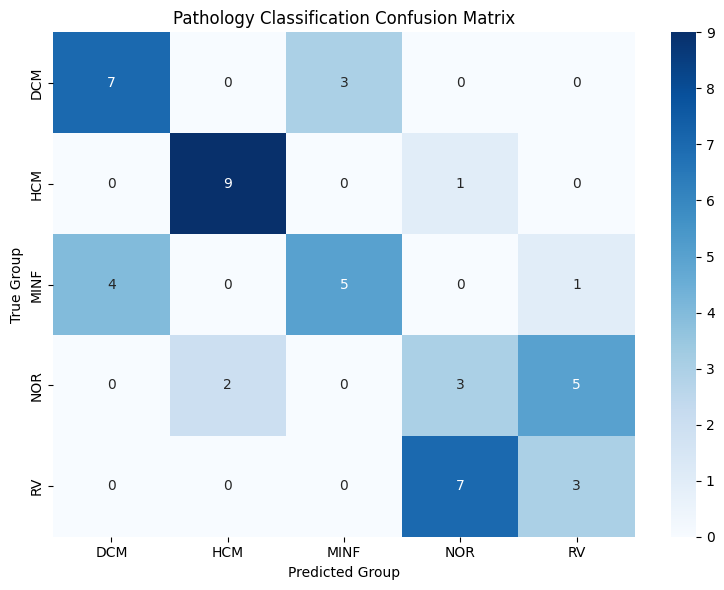


===== FEATURE IMPORTANCE =====
     Feature  Importance
2       EF_%    0.314706
1     ESV_mL    0.295590
3  MyoMass_g    0.249347
0     EDV_mL    0.140357

Saved!


In [ ]:
import torch
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

# Load physiological parameters
df = pd.read_csv("physiological_params.csv")
# Add RV volume as a feature (class 1 in segmentation)
rv_edv = predict_volume(ed_nii, 1)  # RV at ED
rv_esv = predict_volume(es_nii, 1)  # RV at ES
rv_ef  = (rv_edv - rv_esv) / rv_edv * 100

# Features and labels
X = df[["EDV_mL", "ESV_mL", "EF_%", "MyoMass_g"]].values
y = df["Group"].values

le = LabelEncoder()
y_enc = le.fit_transform(y)

# Train classifier (leave-one-out style with all 50 test patients)
from sklearn.model_selection import cross_val_predict, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_pred = cross_val_predict(clf, X, y_enc, cv=cv)
y_pred_labels = le.inverse_transform(y_pred)

# Results
print("===== PATHOLOGY CLASSIFICATION REPORT =====")
print(classification_report(y, y_pred_labels))

# Confusion Matrix
cm = confusion_matrix(y, y_pred_labels, labels=le.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Pathology Classification Confusion Matrix")
plt.ylabel("True Group")
plt.xlabel("Predicted Group")
plt.tight_layout()
plt.savefig("classification_confusion_matrix.png", dpi=150)
plt.show()

# Feature importance
clf.fit(X, y_enc)
importance = pd.DataFrame({
    "Feature": ["EDV_mL","ESV_mL","EF_%","MyoMass_g"],
    "Importance": clf.feature_importances_
}).sort_values("Importance", ascending=False)
print("\n===== FEATURE IMPORTANCE =====")
print(importance)

# Save
importance.to_csv("classification_results.csv", index=False)
shutil.copy("classification_confusion_matrix.png", "/content/drive/MyDrive/msc project/classification_confusion_matrix.png")
shutil.copy("classification_results.csv", "/content/drive/MyDrive/msc project/classification_results.csv")
print("\nSaved!")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/project") if os.path.exists("/content/project") else None

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

data = {
    "Model": ["U-Net", "Attention U-Net", "TransUNet"],
    "Mean Dice": [0.828, 0.830, 0.844],
    "Parameters": ["7.7M", "31.4M", "21.7M"],
    "Inference (ms)": [15.81, 22.31, 13.64],
    "Memory (MB)": [137, 284, 330]
}

df = pd.DataFrame(data)
print(df.to_string(index=False))

          Model  Mean Dice Parameters  Inference (ms)  Memory (MB)
          U-Net      0.828       7.7M           15.81          137
Attention U-Net      0.830      31.4M           22.31          284
      TransUNet      0.844      21.7M           13.64          330


In [ ]:
#setup cell; always required at the start
from google.colab import drive
drive.mount('/content/drive')
import shutil, os, zipfile

os.makedirs("/content/project", exist_ok=True)
for m in ["unet_best.pth", "attention_unet_best.pth", "transunet_best.pth"]:
    shutil.copy(f"/content/drive/MyDrive/msc project/{m}", f"/content/project/{m}")
if not os.path.exists("/content/project/data"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")
os.chdir("/content/project")
print("Done!")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done!
attention_unet_best.pth  test_loader.py		unet_best.pth
data			 train_segmentation.py	unet.py
dataset.py		 transunet_best.pth	visualize_predictions.py


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn.functional as F
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import shutil
from unet import UNet

# ---- Load Model ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(n_classes=4).to(device)
model.load_state_dict(torch.load("/content/project/unet_best.pth"))
model.eval()

# ---- Volume Computation ----
def predict_volume(nii_obj, cls):
    vol = nii_obj.get_fdata()
    spacing = nii_obj.header.get_zooms()
    total_voxels = 0
    for s in range(vol.shape[2]):
        img = torch.tensor(vol[:,:,s], dtype=torch.float32)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256),
                           mode='bilinear', align_corners=False).to(device)
        with torch.no_grad():
            pred = torch.argmax(model(img), dim=1).squeeze().cpu().numpy()
        orig_h, orig_w = vol.shape[0], vol.shape[1]
        pred_orig = F.interpolate(torch.tensor(pred).unsqueeze(0).unsqueeze(0).float(),
                                  size=(orig_h, orig_w), mode='nearest').squeeze().numpy()
        total_voxels += (pred_orig == cls).sum()
    voxel_vol = spacing[0] * spacing[1] * spacing[2]
    return total_voxels * voxel_vol / 1000

# ---- Compute Parameters Including RV ----
results = []
patients = sorted(glob.glob("/content/project/data/testing/patient*"))
print(f"Found {len(patients)} patients")

for patient_path in patients:
    patient_id = os.path.basename(patient_path)
    cfg = {}
    with open(os.path.join(patient_path, "Info.cfg")) as f:
        for line in f:
            k, v = line.strip().split(": ")
            cfg[k] = v
    label = cfg["Group"]
    ed_frame = int(cfg["ED"])
    es_frame = int(cfg["ES"])

    ed_path = os.path.join(patient_path, f"{patient_id}_frame{ed_frame:02d}.nii.gz")
    es_path = os.path.join(patient_path, f"{patient_id}_frame{es_frame:02d}.nii.gz")

    if not os.path.exists(ed_path) or not os.path.exists(es_path):
        continue

    ed_nii = nib.load(ed_path)
    es_nii = nib.load(es_path)

    # LV measurements
    lv_edv = predict_volume(ed_nii, 3)
    lv_esv = predict_volume(es_nii, 3)
    lv_ef  = (lv_edv - lv_esv) / lv_edv * 100 if lv_edv > 0 else 0

    # RV measurements — NEW
    rv_edv = predict_volume(ed_nii, 1)
    rv_esv = predict_volume(es_nii, 1)
    rv_ef  = (rv_edv - rv_esv) / rv_edv * 100 if rv_edv > 0 else 0

    # Myocardial mass
    myo_mass = predict_volume(ed_nii, 2) * 1.05

    results.append({
        "Patient": patient_id, "Group": label,
        "LV_EDV_mL": round(lv_edv, 2), "LV_ESV_mL": round(lv_esv, 2),
        "LV_EF_%":   round(lv_ef, 2),
        "RV_EDV_mL": round(rv_edv, 2), "RV_ESV_mL": round(rv_esv, 2),
        "RV_EF_%":   round(rv_ef, 2),
        "MyoMass_g": round(myo_mass, 2)
    })
    print(f"{patient_id} ({label}) | LV_EF:{lv_ef:.1f}% RV_EDV:{rv_edv:.1f}mL RV_EF:{rv_ef:.1f}%")

df = pd.DataFrame(results)
df.to_csv("/content/extended_params.csv", index=False)
print("\nParameters computed!")

# ---- Classification with All 3 Classifiers ----
X = df[["LV_EDV_mL","LV_ESV_mL","LV_EF_%","RV_EDV_mL","RV_ESV_mL","RV_EF_%","MyoMass_g"]].values
y = df["Group"].values
le = LabelEncoder()
y_enc = le.fit_transform(y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

classifiers = {
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42),
    "SVM (RBF)":         SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
}

accuracy_results = []
for name, clf in classifiers.items():
    X_input = X_scaled if "SVM" in name else X
    y_pred = cross_val_predict(clf, X_input, y_enc, cv=cv)
    y_pred_labels = le.inverse_transform(y_pred)

    print(f"\n===== {name} =====")
    print(classification_report(y, y_pred_labels))

    # Confusion matrix
    cm = confusion_matrix(y, y_pred_labels, labels=le.classes_)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[0].set_title(f"{name} — Raw"); axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[1].set_title(f"{name} — Normalized"); axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
    plt.suptitle(f"Confusion Matrix — {name}", fontsize=13)
    plt.tight_layout()
    fname = f"/content/cm_{name.replace(' ','_').replace('(','').replace(')','')}.png"
    plt.savefig(fname, dpi=150)
    plt.close()
    shutil.copy(fname, f"/content/drive/MyDrive/msc project/{os.path.basename(fname)}")

    acc = (y_pred_labels == y).mean()
    accuracy_results.append({"Classifier": name, "Accuracy": round(acc, 4)})

print("\n===== ACCURACY SUMMARY =====")
print(pd.DataFrame(accuracy_results).to_string(index=False))

# Save extended params
shutil.copy("/content/extended_params.csv", "/content/drive/MyDrive/msc project/extended_params.csv")
print("\nAll saved to Drive!")

Found 50 patients
patient101 (DCM) | LV_EF:30.5% RV_EDV:125.5mL RV_EF:54.7%
patient102 (NOR) | LV_EF:74.8% RV_EDV:94.4mL RV_EF:56.5%
patient103 (MINF) | LV_EF:30.1% RV_EDV:89.4mL RV_EF:67.6%
patient104 (HCM) | LV_EF:87.0% RV_EDV:97.1mL RV_EF:65.9%
patient105 (HCM) | LV_EF:82.9% RV_EDV:113.7mL RV_EF:66.4%
patient106 (DCM) | LV_EF:8.7% RV_EDV:305.4mL RV_EF:20.9%
patient107 (NOR) | LV_EF:61.2% RV_EDV:48.6mL RV_EF:63.8%
patient108 (HCM) | LV_EF:84.5% RV_EDV:176.3mL RV_EF:82.0%
patient109 (RV) | LV_EF:54.2% RV_EDV:196.9mL RV_EF:26.9%
patient110 (NOR) | LV_EF:71.3% RV_EDV:151.1mL RV_EF:40.9%
patient111 (HCM) | LV_EF:66.8% RV_EDV:85.3mL RV_EF:70.5%
patient112 (MINF) | LV_EF:46.6% RV_EDV:141.7mL RV_EF:55.9%
patient113 (DCM) | LV_EF:17.8% RV_EDV:177.0mL RV_EF:37.9%
patient114 (HCM) | LV_EF:76.0% RV_EDV:89.9mL RV_EF:37.0%
patient115 (MINF) | LV_EF:40.7% RV_EDV:115.0mL RV_EF:36.8%
patient116 (HCM) | LV_EF:66.9% RV_EDV:120.7mL RV_EF:70.1%
patient117 (DCM) | LV_EF:27.9% RV_EDV:235.5mL RV_EF:59.0%
p

Using device: cuda

Analysing 50 patients across Base/Mid/Apex regions...
Done: patient101 (DCM)
Done: patient102 (NOR)
Done: patient103 (MINF)
Done: patient104 (HCM)
Done: patient105 (HCM)
Done: patient106 (DCM)
Done: patient107 (NOR)
Done: patient108 (HCM)
Done: patient109 (RV)
Done: patient110 (NOR)
Done: patient111 (HCM)
Done: patient112 (MINF)
Done: patient113 (DCM)
Done: patient114 (HCM)
Done: patient115 (MINF)
Done: patient116 (HCM)
Done: patient117 (DCM)
Done: patient118 (MINF)
Done: patient119 (RV)
Done: patient120 (MINF)
Done: patient121 (RV)
Done: patient122 (DCM)
Done: patient123 (NOR)
Done: patient124 (RV)
Done: patient125 (NOR)
Done: patient126 (RV)
Done: patient127 (RV)
Done: patient128 (NOR)
Done: patient129 (RV)
Done: patient130 (NOR)
Done: patient131 (DCM)
Done: patient132 (DCM)
Done: patient133 (DCM)
Done: patient134 (HCM)
Done: patient135 (MINF)
Done: patient136 (DCM)
Done: patient137 (MINF)
Done: patient138 (HCM)
Done: patient139 (NOR)
Done: patient140 (RV)
Done: p

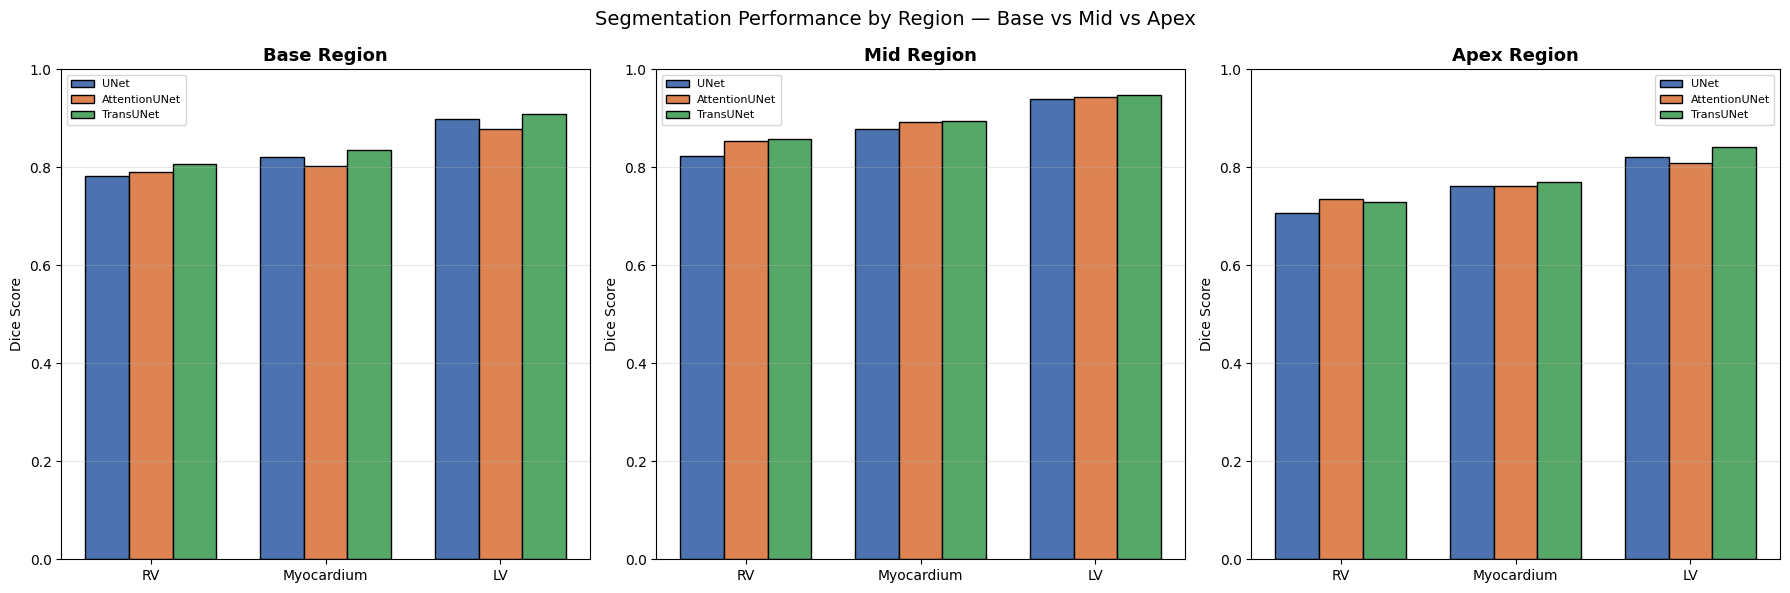

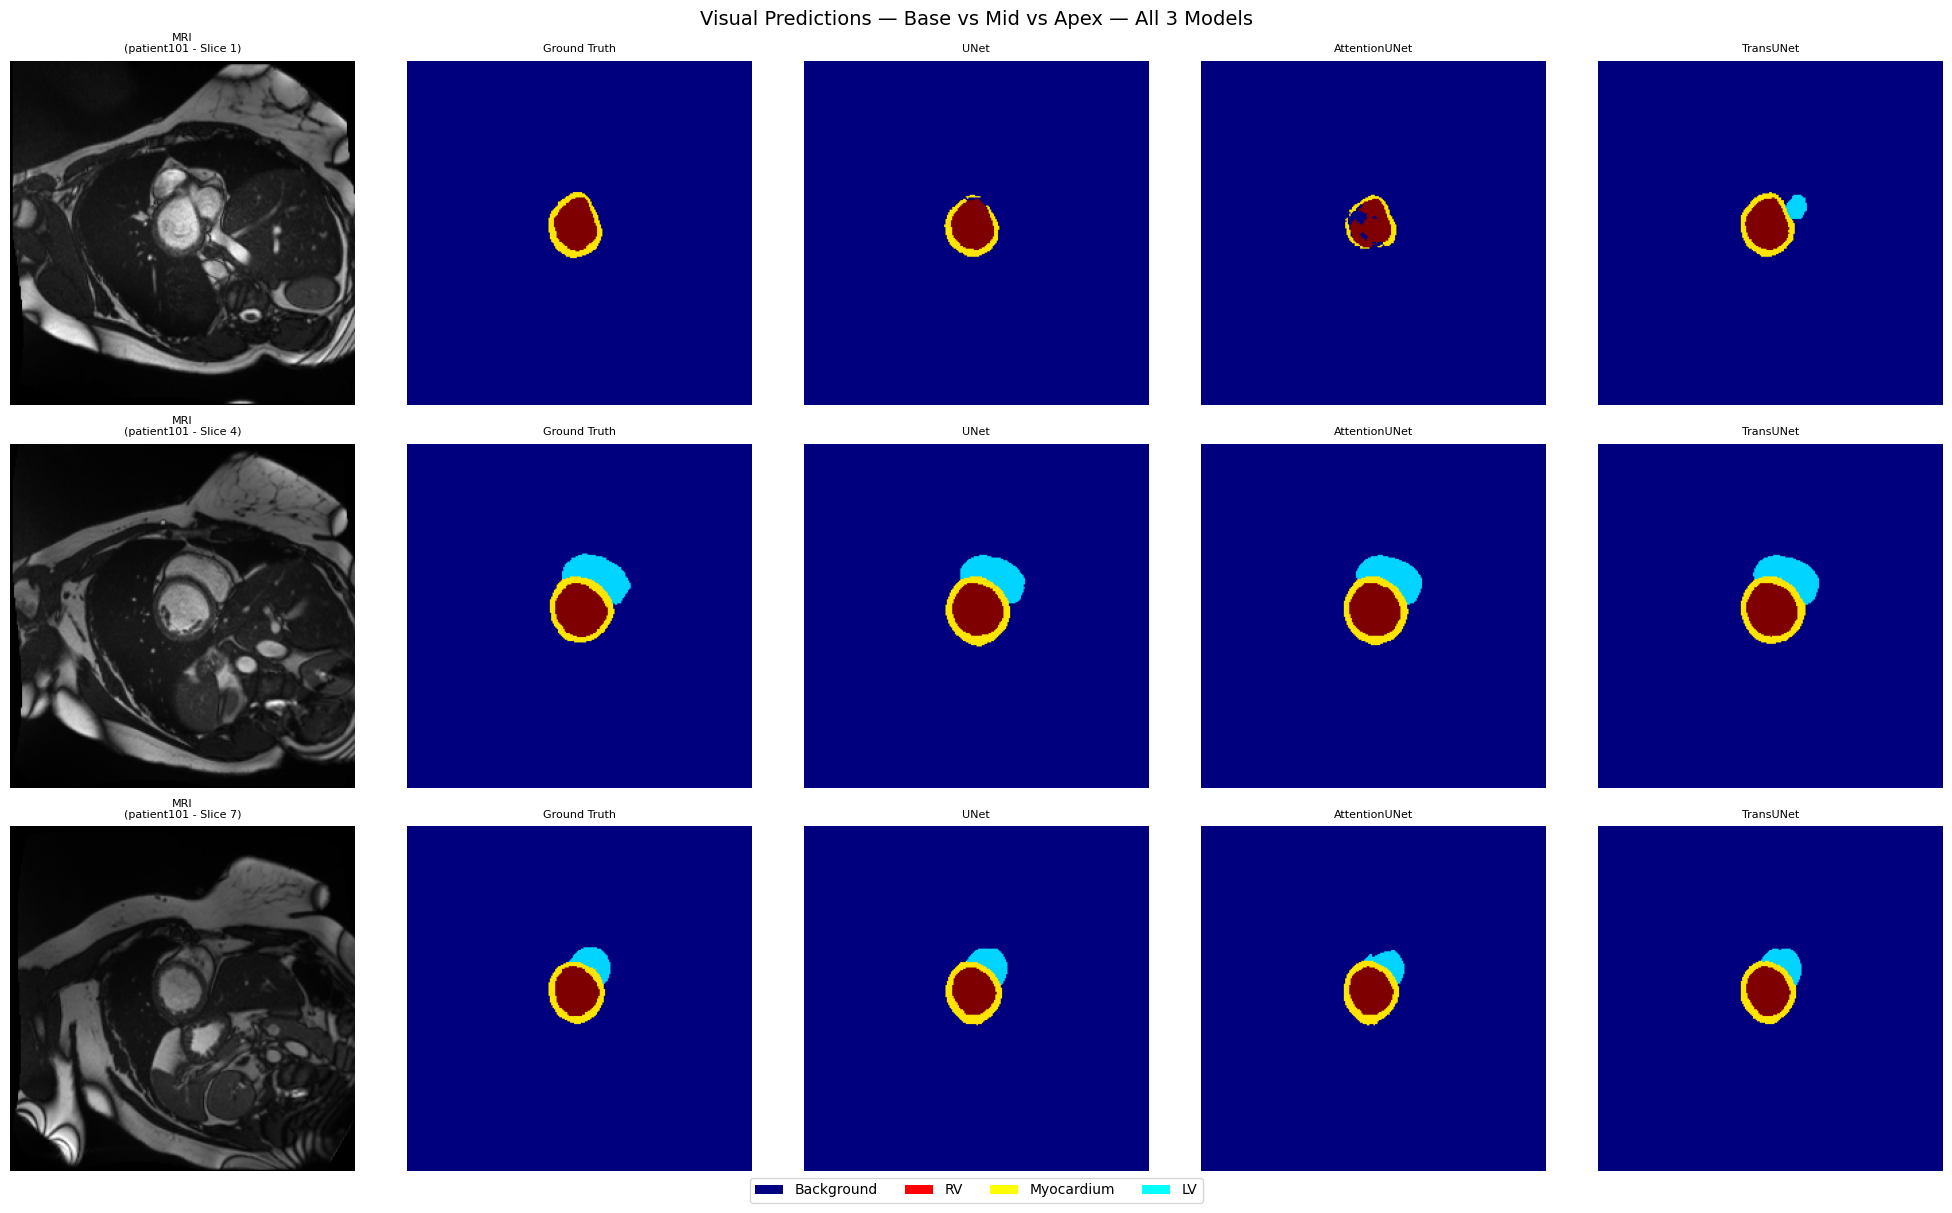


All saved to Drive!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob
import os
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
import shutil
from unet import UNet

# ---- Model Definitions ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64);   self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);  e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*mlp_ratio),nn.GELU(),
                               nn.Dropout(dropout),nn.Linear(emb_dim*mlp_ratio,emb_dim),nn.Dropout(dropout))
    def forward(self, x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Dice Function ----
def dice_per_class(pred, target, cls):
    pred_cls=(pred==cls).float(); tgt_cls=(target==cls).float()
    intersection=(pred_cls*tgt_cls).sum(); union=pred_cls.sum()+tgt_cls.sum()
    return (2.0*intersection+1e-8)/(union+1e-8)

# ---- Load Models ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

models_dict = {
    "UNet": UNet(n_classes=4),
    "AttentionUNet": AttentionUNet(n_classes=4),
    "TransUNet": TransUNet(n_classes=4)
}

# Fixed model loading paths
models_dict["UNet"].load_state_dict(torch.load("unet_best.pth"))
models_dict["AttentionUNet"].load_state_dict(torch.load("attention_unet_best.pth"))
models_dict["TransUNet"].load_state_dict(torch.load("transunet_best.pth"))

for m in models_dict.values():
    m.to(device).eval()

# ---- Region Analysis ----
# Fixed to look in local data folder
patients = sorted(glob.glob("data/testing/patient*"))
results = []
visual_samples = {"Base": None, "Mid": None, "Apex": None}

print(f"\nAnalysing {len(patients)} patients across Base/Mid/Apex regions...")

for patient_path in patients:
    patient_id = os.path.basename(patient_path)
    cfg = {}
    with open(os.path.join(patient_path, "Info.cfg")) as f:
        for line in f:
            k, v = line.strip().split(": ")
            cfg[k] = v
    label = cfg["Group"]

    frames = sorted(glob.glob(os.path.join(patient_path, "*_frame*.nii.gz")))
    frames = [f for f in frames if "_gt" not in f]

    for frame_path in frames:
        gt_path = frame_path.replace(".nii.gz", "_gt.nii.gz")
        if not os.path.exists(gt_path):
            continue

        img_vol = nib.load(frame_path).get_fdata()
        gt_vol  = nib.load(gt_path).get_fdata()
        num_slices = img_vol.shape[2]

        # Define regions
        third = num_slices // 3
        regions = {
            "Base": range(0, third),
            "Mid":  range(third, 2*third),
            "Apex": range(2*third, num_slices)
        }

        for region_name, slice_range in regions.items():
            region_dice = {"RV": [], "Myo": [], "LV": []}

            for s in slice_range:
                img_slice = torch.tensor(img_vol[:,:,s], dtype=torch.float32)
                gt_slice  = torch.tensor(gt_vol[:,:,s], dtype=torch.long)
                img_norm  = (img_slice - img_slice.mean()) / (img_slice.std() + 1e-8)
                img_input = F.interpolate(img_norm.unsqueeze(0).unsqueeze(0),
                                         size=(256,256), mode='bilinear', align_corners=False).to(device)
                gt_resized = F.interpolate(gt_slice.float().unsqueeze(0).unsqueeze(0),
                                          size=(256,256), mode='nearest').squeeze().long()

                for model_name, model in models_dict.items():
                    with torch.no_grad():
                        pred = torch.argmax(model(img_input), dim=1).squeeze().cpu()

                    for cls_idx, cls_name in [(1,"RV"),(2,"Myo"),(3,"LV")]:
                        dice = dice_per_class(pred, gt_resized, cls_idx).item()
                        results.append({
                            "Patient": patient_id, "Group": label,
                            "Region": region_name, "Model": model_name,
                            "Structure": cls_name, "Dice": round(dice, 4)
                        })

                    # Save visual sample (one per region)
                    if visual_samples[region_name] is None and gt_resized.sum() > 100:
                        visual_samples[region_name] = {
                            "img": img_input.squeeze().cpu().numpy(),
                            "gt": gt_resized.numpy(),
                            "preds": {},
                            "patient": patient_id,
                            "slice": s,
                            "region": region_name
                        }

                if visual_samples[region_name] is not None and "preds" in visual_samples[region_name]:
                    if len(visual_samples[region_name]["preds"]) < 3:
                        for model_name, model in models_dict.items():
                            if model_name not in visual_samples[region_name]["preds"]:
                                with torch.no_grad():
                                    pred = torch.argmax(model(img_input), dim=1).squeeze().cpu().numpy()
                                visual_samples[region_name]["preds"][model_name] = pred

    print(f"Done: {patient_id} ({label})")

# ---- Save Results ----
df = pd.DataFrame(results)
# Fixed local path
df.to_csv("region_analysis.csv", index=False)

# ---- Summary Table ----
summary = df.groupby(["Model","Region","Structure"])["Dice"].mean().round(4).reset_index()
pivot = summary.pivot_table(index=["Model","Region"], columns="Structure", values="Dice").reset_index()
pivot["Mean"] = pivot[["RV","Myo","LV"]].mean(axis=1).round(4)
print(df.columns)
print("\n===== REGION ANALYSIS SUMMARY =====")
print(pivot.to_string(index=False))

# ---- Bar Chart ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regions = ["Base", "Mid", "Apex"]
colors  = {"UNet": "#4C72B0", "AttentionUNet": "#DD8452", "TransUNet": "#55A868"}

for ax, region in zip(axes, regions):
    region_df = summary[summary["Region"] == region]
    x = np.arange(3)
    width = 0.25
    for i, (model_name, color) in enumerate(colors.items()):
        model_df = region_df[region_df["Model"] == model_name]
        scores = [model_df[model_df["Structure"]==s]["Dice"].values[0]
                  if len(model_df[model_df["Structure"]==s]) > 0 else 0
                  for s in ["RV","Myo","LV"]]
        ax.bar(x + i*width, scores, width, label=model_name, color=color, edgecolor="black")
    ax.set_title(f"{region} Region", fontsize=13, fontweight="bold")
    ax.set_xticks(x + width); ax.set_xticklabels(["RV","Myocardium","LV"])
    ax.set_ylim(0, 1.0); ax.set_ylabel("Dice Score")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Segmentation Performance by Region — Base vs Mid vs Apex", fontsize=14)
plt.tight_layout()
# Fixed local path
plt.savefig("region_comparison.png", dpi=150)
plt.show()

# ---- Visual Predictions per Region ----
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
col_titles = ["MRI", "Ground Truth", "U-Net", "Attention U-Net", "TransUNet"]
row_titles = ["Base", "Mid", "Apex"]

for row_idx, region in enumerate(["Base", "Mid", "Apex"]):
    sample = visual_samples[region]
    axes[row_idx, 0].imshow(sample["img"], cmap="gray")
    axes[row_idx, 0].set_title(f"MRI\n({sample['patient']} - Slice {sample['slice']+1})", fontsize=8)
    axes[row_idx, 1].imshow(sample["gt"], cmap="jet", vmin=0, vmax=3)
    axes[row_idx, 1].set_title("Ground Truth", fontsize=8)
    for col_idx, model_name in enumerate(["UNet","AttentionUNet","TransUNet"]):
        axes[row_idx, col_idx+2].imshow(sample["preds"][model_name], cmap="jet", vmin=0, vmax=3)
        axes[row_idx, col_idx+2].set_title(model_name, fontsize=8)
    axes[row_idx, 0].set_ylabel(f"{region} Region", fontsize=11, fontweight="bold")
    for ax in axes[row_idx]:
        ax.axis("off")

# Legend
legend_elements = [
    mpatches.Patch(facecolor='navy',  label='Background'),
    mpatches.Patch(facecolor='red',   label='RV'),
    mpatches.Patch(facecolor='yellow',label='Myocardium'),
    mpatches.Patch(facecolor='cyan',  label='LV')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Visual Predictions — Base vs Mid vs Apex — All 3 Models", fontsize=14)
plt.tight_layout()
# Fixed local path
plt.savefig("region_visual.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Save to Drive ----
for f in ["region_analysis.csv", "region_comparison.png", "region_visual.png"]:
    # Fixed Windows G: Drive path
    shutil.copy(f, f"G:/My Drive/msc project/{f}")
print("\nAll saved to Drive!")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil, os, zipfile

os.makedirs("/content/project", exist_ok=True)
shutil.copy("/content/drive/MyDrive/msc project/unet_best.pth", "/content/project/unet_best.pth")
if not os.path.exists("/content/project/data"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")
os.chdir("/content/project")
print("Done!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

In [ ]:
dataset_code = '''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            key, value = line.strip().split(": ")
            info[key] = value
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []
        self.augment = augment
        patients = sorted(glob.glob(os.path.join(root_dir, "training", "patient*")))
        for patient in patients:
            frames = glob.glob(os.path.join(patient, "*_frame*.nii.gz"))
            for f in frames:
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        img_vol  = nib.load(f).get_fdata()
                        mask_vol = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(img_vol.shape[2]):
                            self.samples.append((img_vol[:,:,s], mask_vol[:,:,s], label))

    def __len__(self):
        return len(self.samples)

    def apply_augmentation(self, img, mask):
        img_pil  = TF.to_pil_image(img.unsqueeze(0))
        mask_pil = TF.to_pil_image(mask.unsqueeze(0).byte())
        if random.random() > 0.5:
            img_pil  = TF.hflip(img_pil)
            mask_pil = TF.hflip(mask_pil)
        if random.random() > 0.5:
            img_pil  = TF.vflip(img_pil)
            mask_pil = TF.vflip(mask_pil)
        angle = random.uniform(-15, 15)
        img_pil  = TF.rotate(img_pil,  angle)
        mask_pil = TF.rotate(mask_pil, angle)
        if random.random() > 0.5:
            img_pil = TF.adjust_brightness(img_pil, random.uniform(0.8, 1.2))
            img_pil = TF.adjust_contrast(img_pil,   random.uniform(0.8, 1.2))
        img  = TF.to_tensor(img_pil).squeeze(0)
        mask = torch.from_numpy(np.array(mask_pil)).long()
        return img, mask

    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img  = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img  = (img - img.mean()) / (img.std() + 1e-8)
        img  = F.interpolate(img.unsqueeze(0).unsqueeze(0),  size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long()
        if self.augment:
            img, mask = self.apply_augmentation(img.squeeze(0), mask.squeeze(0))
            img = img.unsqueeze(0)
        mask = mask.squeeze(0)
        return img, mask, label
'''

with open("/content/project/dataset.py", "w") as f:
    f.write(dataset_code)
print("dataset.py written!")

dataset.py written!


In [ ]:
import os
os.chdir("/content/project")

In [ ]:
from google.colab import files
files.upload()  # select unet.py from your PC

Saving unet.py to unet.py


{'unet.py': b'import torch\r\nimport torch.nn as nn\r\n\r\n\r\n# Basic double convolution block\r\nclass DoubleConv(nn.Module):\r\n    def __init__(self, in_channels, out_channels):\r\n        super(DoubleConv, self).__init__()\r\n        self.double_conv = nn.Sequential(\r\n            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),\r\n            nn.BatchNorm2d(out_channels),\r\n            nn.ReLU(inplace=True),\r\n            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),\r\n            nn.BatchNorm2d(out_channels),\r\n            nn.ReLU(inplace=True)\r\n        )\r\n\r\n    def forward(self, x):\r\n        return self.double_conv(x)\r\n\r\n\r\nclass UNet(nn.Module):\r\n    def __init__(self, n_classes=4):\r\n        super(UNet, self).__init__()\r\n\r\n        # Encoder\r\n        self.enc1 = DoubleConv(1, 64)\r\n        self.enc2 = DoubleConv(64, 128)\r\n        self.enc3 = DoubleConv(128, 256)\r\n        self.enc4 = DoubleConv(256, 512)\r\n\r\n 

In [ ]:
import zipfile, os
if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")
    print("Extracted!")
else:
    print("Data already there!")
!ls /content/project/data

Data already there!
LICENSE_TERMS.md       script_acdc_visu.ipynb		  testing
MANDATORY_CITATION.md  STATE-OF-THE-ART-nnUNet-method.md  training


In [ ]:
import glob
patients = glob.glob("/content/project/data/training/patient*")
print(f"Patients found: {len(patients)}")
print(patients[:3])

Patients found: 100
['/content/project/data/training/patient022', '/content/project/data/training/patient039', '/content/project/data/training/patient032']


In [ ]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
    z.extractall("/content/project")
print("Done!")

import glob
print(f"Patients: {len(glob.glob('/content/project/data/training/patient*'))}")

Done!
Patients: 100


In [ ]:
dataset_code = '''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            key, value = line.strip().split(": ")
            info[key] = value
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []
        self.augment = augment
        patients = sorted(glob.glob(os.path.join(root_dir, "training", "patient*")))
        for patient in patients:
            frames = glob.glob(os.path.join(patient, "*_frame*.nii.gz"))
            for f in frames:
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        img_vol  = nib.load(f).get_fdata()
                        mask_vol = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(img_vol.shape[2]):
                            self.samples.append((img_vol[:,:,s], mask_vol[:,:,s], label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img  = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img  = (img - img.mean()) / (img.std() + 1e-8)
        img  = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long().squeeze(0)

        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            # Random vertical flip
            if random.random() > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            # Random 90 degree rotation
            if random.random() > 0.5:
                k = random.randint(1, 3)
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])

        return img, mask, label
'''

with open("/content/project/dataset.py", "w") as f:
    f.write(dataset_code)
print("Fixed dataset.py written!")

Fixed dataset.py written!


In [ ]:
def dice_score(pred, target):
    dice=0.0
    pred_cls = torch.argmax(pred, dim=1)
    for cls in range(1,4):
        p=(pred_cls==cls).float()
        t=(target==cls).float()
        intersection=(p*t).sum()
        union=p.sum()+t.sum()
        if union > 0:
            dice += (2*intersection+1e-8)/(union+1e-8)
    return dice/3

In [ ]:
print(f"Mask unique values: {target.unique()}")
print(f"Pred unique values: {pred_cls.unique()}")

NameError: name 'target' is not defined

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet

device = torch.device("cuda")
dataset = ACDCDataset("data", augment=False)
loader  = DataLoader(dataset, batch_size=4, shuffle=True)
imgs, masks, _ = next(iter(loader))

print(f"Mask unique values: {masks.unique()}")
print(f"Mask shape: {masks.shape}")
print(f"Image shape: {imgs.shape}")

model = UNet(n_classes=4).to(device)
with torch.no_grad():
    pred = model(imgs.to(device))
pred_cls = torch.argmax(pred, dim=1)
print(f"Pred unique values: {pred_cls.unique()}")

Mask unique values: tensor([0, 1, 2, 3])
Mask shape: torch.Size([4, 256, 256])
Image shape: torch.Size([4, 1, 256, 256])


AssertionError: Torch not compiled with CUDA enabled

In [ ]:
import torch
from dataset import ACDCDataset
from unet import UNet
from torch.utils.data import DataLoader, random_split

device = torch.device("cuda")
dataset = ACDCDataset("data", augment=False)
train_size = int(0.8*len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
val_loader = DataLoader(val_ds, batch_size=4)

model = UNet(n_classes=4).to(device)

imgs, masks, _ = next(iter(val_loader))
imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    pred = model(imgs)

pred_cls = torch.argmax(pred, dim=1)
print(f"Pred unique: {pred_cls.unique()}")
print(f"Mask unique: {masks.unique()}")

for cls in range(1,4):
    p = (pred_cls==cls).float()
    t = (masks==cls).float()
    intersection = (p*t).sum()
    union = p.sum() + t.sum()
    dice = (2*intersection+1e-8)/(union+1e-8)
    print(f"Class {cls} — pred pixels: {p.sum().item():.0f} | gt pixels: {t.sum().item():.0f} | Dice: {dice.item():.4f}")

Pred unique: tensor([0, 1, 2, 3], device='cuda:0')
Mask unique: tensor([0, 1, 2, 3], device='cuda:0')
Class 1 — pred pixels: 136866 | gt pixels: 4151 | Dice: 0.0084
Class 2 — pred pixels: 31517 | gt pixels: 4947 | Dice: 0.0297
Class 3 — pred pixels: 59291 | gt pixels: 3406 | Dice: 0.0434


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm
import shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset    = ACDCDataset("data", augment=True)
train_size = int(0.8 * len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

model     = UNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def dice_score(pred, target):
    dice = 0.0
    pred = torch.argmax(pred, dim=1)
    for cls in range(1, 4):
        p = (pred==cls).float()
        t = (target==cls).float()
        intersection = (p*t).sum()
        union = p.sum() + t.sum()
        dice += (2*intersection+1e-8)/(union+1e-8)
    return dice/3

best_dice = 0.0
for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs, masks, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/50"):
        imgs  = imgs.to(device)
        masks = masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
    scheduler.step()

    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            outputs = model(imgs)
            val_dice += dice_score(outputs, masks).item()

    avg_dice = val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "unet_best_v2.pth")
        print("Best saved!")

print(f"\nBest Dice: {best_dice:.4f}")
shutil.copy("unet_best_v2.pth", "/content/drive/MyDrive/msc project/unet_best_v2.pth")

ModuleNotFoundError: No module named 'dataset'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil, os, zipfile

os.makedirs("/content/project", exist_ok=True)
for m in ["unet_best_v2.pth"]:
    shutil.copy(f"/content/drive/MyDrive/msc project/{m}", f"/content/project/{m}")
if not os.path.exists("/content/project/data"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")
os.chdir("/content/project")
print("Done!")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.upload()  # select unet.py from your PC

Saving unet.py to unet.py


{'unet.py': b'import torch\r\nimport torch.nn as nn\r\n\r\n\r\n# Basic double convolution block\r\nclass DoubleConv(nn.Module):\r\n    def __init__(self, in_channels, out_channels):\r\n        super(DoubleConv, self).__init__()\r\n        self.double_conv = nn.Sequential(\r\n            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),\r\n            nn.BatchNorm2d(out_channels),\r\n            nn.ReLU(inplace=True),\r\n            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),\r\n            nn.BatchNorm2d(out_channels),\r\n            nn.ReLU(inplace=True)\r\n        )\r\n\r\n    def forward(self, x):\r\n        return self.double_conv(x)\r\n\r\n\r\nclass UNet(nn.Module):\r\n    def __init__(self, n_classes=4):\r\n        super(UNet, self).__init__()\r\n\r\n        # Encoder\r\n        self.enc1 = DoubleConv(1, 64)\r\n        self.enc2 = DoubleConv(64, 128)\r\n        self.enc3 = DoubleConv(128, 256)\r\n        self.enc4 = DoubleConv(256, 512)\r\n\r\n 

In [ ]:
with open("/content/project/dataset.py", "w") as f:
    f.write('''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            key, value = line.strip().split(": ")
            info[key] = value
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []
        self.augment = augment
        patients = sorted(glob.glob(os.path.join(root_dir, "training", "patient*")))
        for patient in patients:
            frames = glob.glob(os.path.join(patient, "*_frame*.nii.gz"))
            for f in frames:
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        img_vol  = nib.load(f).get_fdata()
                        mask_vol = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(img_vol.shape[2]):
                            self.samples.append((img_vol[:,:,s], mask_vol[:,:,s], label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img  = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img  = (img - img.mean()) / (img.std() + 1e-8)
        img  = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long().squeeze(0)
        if self.augment:
            if random.random() > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            if random.random() > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            if random.random() > 0.5:
                k = random.randint(1,3)
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])
        return img, mask, label
''')
print("Done!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/project/dataset.py'

In [ ]:
import os
os.chdir("/content/project")
print(os.listdir("."))

FileNotFoundError: [Errno 2] No such file or directory: '/content/project'

In [ ]:
import shutil
shutil.move("/content/unet.py", "/content/project/unet.py")
print("Done!")

Done!


In [ ]:
import zipfile, glob

with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
    z.extractall("/content/project")

print(f"Patients: {len(glob.glob('/content/project/data/training/patient*'))}")

Patients: 100


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm
import shutil

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64);   self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2);  self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2);  self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2);   self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b);  e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ACDCDataset("data", augment=True)
train_size = int(0.8*len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)

model     = AttentionUNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for cls in range(1,4):
        p=(pred==cls).float(); t=(target==cls).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

best_dice=0.0
for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs,masks,_ in tqdm(train_loader, desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        loss=criterion(model(imgs),masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
    scheduler.step()
    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs,masks,_ in val_loader:
            imgs,masks=imgs.to(device),masks.to(device)
            val_dice+=dice_score(model(imgs),masks).item()
    avg_dice=val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")
    if avg_dice>best_dice:
        best_dice=avg_dice
        torch.save(model.state_dict(), "attention_unet_best_v2.pth")
        print("Best saved!")

print(f"\nBest Dice: {best_dice:.4f}")
shutil.copy("attention_unet_best_v2.pth", "/content/drive/MyDrive/msc project/attention_unet_best_v2.pth")

Epoch 1/50: 100%|██████████| 191/191 [01:56<00:00,  1.64it/s]


Epoch 1 | Loss: 0.2850 | Dice: 0.0246
Best saved!


Epoch 2/50: 100%|██████████| 191/191 [01:55<00:00,  1.65it/s]


Epoch 2 | Loss: 0.0961 | Dice: 0.3870
Best saved!


Epoch 3/50: 100%|██████████| 191/191 [01:56<00:00,  1.64it/s]


...

Epoch 49/50: 100%|██████████| 191/191 [01:56<00:00,  1.64it/s]


Epoch 49 | Loss: 0.0092 | Dice: 0.9165


Epoch 50/50: 100%|██████████| 191/191 [01:56<00:00,  1.64it/s]


Epoch 50 | Loss: 0.0091 | Dice: 0.9149

Best Dice: 0.9169


'/content/drive/MyDrive/msc project/attention_unet_best_v2.pth'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import shutil, os, zipfile, glob

os.makedirs("/content/project", exist_ok=True)

# Copy models
for m in ["unet_best_v2.pth"]:
    shutil.copy(f"/content/drive/MyDrive/msc project/{m}", f"/content/project/{m}")

# Extract data
with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
    z.extractall("/content/project")

print(f"Patients: {len(glob.glob('/content/project/data/training/patient*'))}")

os.chdir("/content/project")
print("Done!")
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Patients: 100
Done!
data	    test_loader.py	   unet_best_v2.pth  visualize_predictions.py
dataset.py  train_segmentation.py  unet.py


In [ ]:
import importlib, dataset
importlib.reload(dataset)
from dataset import ACDCDataset

ModuleNotFoundError: No module named 'dataset'

In [ ]:
import os
os.chdir("/content/project")

with open("dataset.py", "w") as f:
    f.write('''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            key, value = line.strip().split(": ")
            info[key] = value
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []
        self.augment = augment
        patients = sorted(glob.glob(os.path.join(root_dir, "training", "patient*")))
        for patient in patients:
            frames = glob.glob(os.path.join(patient, "*_frame*.nii.gz"))
            for f in frames:
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        img_vol  = nib.load(f).get_fdata()
                        mask_vol = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(img_vol.shape[2]):
                            self.samples.append((img_vol[:,:,s], mask_vol[:,:,s], label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img  = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img  = torch.tensor(img,  dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img  = (img - img.mean()) / (img.std() + 1e-8)
        img  = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long().squeeze(0)
        if self.augment:
            if random.random() > 0.5:
                img  = torch.flip(img,  [-1])
                mask = torch.flip(mask, [-1])
            if random.random() > 0.5:
                img  = torch.flip(img,  [-2])
                mask = torch.flip(mask, [-2])
            if random.random() > 0.5:
                k = random.randint(1,3)
                img  = torch.rot90(img,  k, [-2,-1])
                mask = torch.rot90(mask, k, [-2,-1])
        return img, mask, label
''')

import importlib, dataset
importlib.reload(dataset)
from dataset import ACDCDataset
print("Done!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/project'

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm
import shutil

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self, in_ch=512, emb_dim=512):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=1)
    def forward(self, x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2), H, W

class TransformerBlock(nn.Module):
    def __init__(self, emb_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self, x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self, n_classes=4, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ACDCDataset("data", augment=True)
train_size = int(0.8*len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)

model     = TransUNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for cls in range(1,4):
        p=(pred==cls).float(); t=(target==cls).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

best_dice=0.0
for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs,masks,_ in tqdm(train_loader, desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        loss=criterion(model(imgs),masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
    scheduler.step()
    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs,masks,_ in val_loader:
            imgs,masks=imgs.to(device),masks.to(device)
            val_dice+=dice_score(model(imgs),masks).item()
    avg_dice=val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")
    if avg_dice>best_dice:
        best_dice=avg_dice
        torch.save(model.state_dict(), "transunet_best_v2.pth")
        print("Best saved!")

print(f"\nBest Dice: {best_dice:.4f}")
shutil.copy("transunet_best_v2.pth", "/content/drive/MyDrive/msc project/transunet_best_v2.pth")

Epoch 1/50: 100%|██████████| 191/191 [01:12<00:00,  2.64it/s]


Epoch 1 | Loss: 0.3916 | Dice: 0.0338
Best saved!


Epoch 2/50: 100%|██████████| 191/191 [01:19<00:00,  2.40it/s]


Epoch 2 | Loss: 0.1327 | Dice: 0.2800
Best saved!


Epoch 3/50: 100%|██████████| 191/191 [01:19<00:00,  2.42it/s]


...

Epoch 49/50: 100%|██████████| 191/191 [01:19<00:00,  2.41it/s]


Epoch 49 | Loss: 0.0113 | Dice: 0.9108


Epoch 50/50: 100%|██████████| 191/191 [01:19<00:00,  2.40it/s]


Epoch 50 | Loss: 0.0113 | Dice: 0.9142
Best saved!

Best Dice: 0.9142


'/content/drive/MyDrive/msc project/transunet_best_v2.pth'

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm
import shutil

# ---- TransUNet with Classification Head ----
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNetWithHead(nn.Module):
    def __init__(self, n_seg_classes=4, n_path_classes=5, emb_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        # Shared CNN Encoder
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)

        # Transformer Bottleneck
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim)
        self.proj_back=nn.Conv2d(emb_dim,512,1)

        # Segmentation Decoder
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.seg_head=nn.Conv2d(32,n_seg_classes,1)

        # Classification Head
        self.cls_head=nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pool
            nn.Flatten(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,n_path_classes)
        )

    def forward(self, x):
        # Shared Encoder
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)

        # Transformer
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))

        # Segmentation output
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        seg_out = self.seg_head(d1)

        # Classification output from bottleneck
        cls_out = self.cls_head(x_t)

        return seg_out, cls_out

# ---- Label encoder ----
LABEL_MAP = {"DCM":0, "HCM":1, "MINF":2, "NOR":3, "RV":4}

# ---- Combined Loss ----
class MultiTaskLoss(nn.Module):
    def __init__(self, seg_weight=0.7, cls_weight=0.3):
        super().__init__()
        self.seg_weight=seg_weight
        self.cls_weight=cls_weight

    def dice_loss(self, ps, t):
        loss=0.0
        for cls in range(1,4):
            p=ps[:,cls]; g=(t==cls).float()
            loss+=1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        return loss/3

    def forward(self, seg_pred, seg_target, cls_pred, cls_target):
        ps=F.softmax(seg_pred,dim=1)
        seg_loss = F.cross_entropy(seg_pred,seg_target) + self.dice_loss(ps,seg_target)
        cls_loss = F.cross_entropy(cls_pred,cls_target)
        return self.seg_weight*seg_loss + self.cls_weight*cls_loss

# ---- Dice Score ----
def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for cls in range(1,4):
        p=(pred==cls).float(); t=(target==cls).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

# ---- Training ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset    = ACDCDataset("data", augment=True)
train_size = int(0.8*len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

model     = TransUNetWithHead(n_seg_classes=4, n_path_classes=5).to(device)
criterion = MultiTaskLoss(seg_weight=0.7, cls_weight=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_dice=0.0
for epoch in range(50):
    model.train(); train_loss=0.0; train_cls_correct=0; train_cls_total=0
    for imgs,masks,labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/50"):
        imgs   = imgs.to(device)
        masks  = masks.to(device)
        cls_gt = torch.tensor([LABEL_MAP[l] for l in labels]).to(device)

        seg_out, cls_out = model(imgs)
        loss = criterion(seg_out, masks, cls_out, cls_gt)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
        train_cls_correct += (cls_out.argmax(1)==cls_gt).sum().item()
        train_cls_total   += len(labels)
    scheduler.step()

    model.eval(); val_dice=0.0; val_cls_correct=0; val_cls_total=0
    with torch.no_grad():
        for imgs,masks,labels in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            cls_gt = torch.tensor([LABEL_MAP[l] for l in labels]).to(device)
            seg_out, cls_out = model(imgs)
            val_dice += dice_score(seg_out, masks).item()
            val_cls_correct += (cls_out.argmax(1)==cls_gt).sum().item()
            val_cls_total   += len(labels)

    avg_dice = val_dice/len(val_loader)
    cls_acc  = val_cls_correct/val_cls_total*100
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f} | Cls Acc: {cls_acc:.1f}%")

    if avg_dice>best_dice:
        best_dice=avg_dice
        torch.save(model.state_dict(), "transunet_head_best.pth")
        print("Best saved!")

print(f"\nBest Dice: {best_dice:.4f}")
shutil.copy("transunet_head_best.pth", "/content/drive/MyDrive/msc project/transunet_head_best.pth")

Using device: cuda
Train: 1521 | Val: 381


Epoch 1/50: 100%|██████████| 191/191 [01:20<00:00,  2.37it/s]


Epoch 1 | Loss: 1.3447 | Dice: 0.1172 | Cls Acc: 18.4%
Best saved!


Epoch 2/50: 100%|██████████| 191/191 [01:19<00:00,  2.39it/s]


Epoch 2 | Loss: 0.9898 | Dice: 0.3640 | Cls Acc: 25.7%
Best saved!


...

Epoch 18 | Loss: 0.6323 | Dice: 0.8276 | Cls Acc: 25.7%


Epoch 19/50: 100%|██████████| 191/191 [01:19<00:00,  2.40it/s]


Epoch 19 | Loss: 0.6141 | Dice: 0.8664 | Cls Acc: 25.7%
Best saved!


Epoch 20/50:  81%|████████  | 155/191 [01:05<00:15,  2.37it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "transunet_head_checkpoint.pth")
import shutil
shutil.copy("transunet_head_checkpoint.pth", "/content/drive/MyDrive/msc project/transunet_head_checkpoint.pth")
print("Saved!")

Saved!


In [ ]:
class DACLLoss(nn.Module):
    def __init__(self, l1=0.001, l2=0.001, l3=0.001, l4=0.001):
        super().__init__()
        self.l1=l1; self.l2=l2; self.l3=l3; self.l4=l4

    def dice_loss(self, ps, t):
        loss=0.0
        for cls in range(1,4):
            p=ps[:,cls]; g=(t==cls).float()
            loss+=1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        return loss/3

    def forward(self, pred, target):
        ps = F.softmax(pred, dim=1)
        ce = F.cross_entropy(pred, target)
        dice = self.dice_loss(ps, target)
        scale = 256 * 256
        vol_loss = sum(F.l1_loss(
            ps[:,c].sum(dim=(1,2))/scale,
            (target==c).float().sum(dim=(1,2))/scale
        ) for c in range(1,4)) / 3
        lp = ps[:,3].sum(dim=(1,2))/scale
        lg = (target==3).float().sum(dim=(1,2))/scale
        ef_loss = F.mse_loss(lp, lg)
        mass_loss = F.l1_loss(
            ps[:,2].sum(dim=(1,2))/scale,
            (target==2).float().sum(dim=(1,2))/scale
        )
        temp_loss = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice + self.l1*vol_loss + self.l2*ef_loss + self.l3*mass_loss + self.l4*temp_loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm
import shutil

# ---- DACL Loss ----

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

criterion = SimpleDACL()
print("Done!")

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for cls in range(1,4):
        p=(pred==cls).float(); t=(target==cls).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

# ---- Model Definitions ----
class ConvBlock(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self,F_g,F_l,F_int):
        super().__init__()
        self.W_g=nn.Sequential(nn.Conv2d(F_g,F_int,1),nn.BatchNorm2d(F_int))
        self.W_x=nn.Sequential(nn.Conv2d(F_l,F_int,1),nn.BatchNorm2d(F_int))
        self.psi=nn.Sequential(nn.Conv2d(F_int,1,1),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(inplace=True)
    def forward(self,g,x): return x*self.psi(self.relu(self.W_g(g)+self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self,n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64); self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2); self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2); self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2); self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b); e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2); self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2); self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

# ---- Train Function ----
def train_dacl(model, model_name, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = ACDCDataset("data", augment=True)
    train_size = int(0.8*len(dataset))
    train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=8)
    print(f"\n{'='*40}\nTraining {model_name} with DACL | Train:{len(train_ds)} Val:{len(val_ds)}\n{'='*40}")

    model=model.to(device)
    criterion=DACLLoss()
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_dice=0.0

    for epoch in range(epochs):
        model.train(); train_loss=0.0
        for imgs,masks,_ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs,masks=imgs.to(device),masks.to(device)
            loss=criterion(model(imgs),masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss+=loss.item()
        scheduler.step()

        model.eval(); val_dice=0.0
        with torch.no_grad():
            for imgs,masks,_ in val_loader:
                imgs,masks=imgs.to(device),masks.to(device)
                val_dice+=dice_score(model(imgs),masks).item()

        avg_dice=val_dice/len(val_loader)
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")
        if avg_dice>best_dice:
            best_dice=avg_dice
            torch.save(model.state_dict(), f"{model_name}_dacl.pth")
            print("Best saved!")

    print(f"\n{model_name} Best DACL Dice: {best_dice:.4f}")
    shutil.copy(f"{model_name}_dacl.pth", f"/content/drive/MyDrive/msc project/{model_name}_dacl.pth")
    return best_dice

# ---- Run All 3 ----
results = {}
results["unet"]          = train_dacl(UNet(n_classes=4),          "unet")
results["attention_unet"]= train_dacl(AttentionUNet(n_classes=4), "attention_unet")
results["transunet"]     = train_dacl(TransUNet(n_classes=4),      "transunet")

print("\n===== DACL FINAL RESULTS =====")
for name, dice in results.items():
    print(f"{name}: {dice:.4f}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm
import shutil

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for cls in range(1,4):
        p=(pred==cls).float(); t=(target==cls).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

class ConvBlock(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self,F_g,F_l,F_int):
        super().__init__()
        self.W_g=nn.Sequential(nn.Conv2d(F_g,F_int,1),nn.BatchNorm2d(F_int))
        self.W_x=nn.Sequential(nn.Conv2d(F_l,F_int,1),nn.BatchNorm2d(F_int))
        self.psi=nn.Sequential(nn.Conv2d(F_int,1,1),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(inplace=True)
    def forward(self,g,x): return x*self.psi(self.relu(self.W_g(g)+self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self,n_classes=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64); self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2); self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2); self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2); self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b); e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2); self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2); self.dec1=ConvBlock(32+64,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4); d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3); d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2); d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.final(d1)

def train_dacl(model, model_name, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = ACDCDataset("data")   # <-- removed augment=True, class doesn't support it
    train_size = int(0.8*len(dataset))
    train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=8)
    print(f"\n{'='*40}\nTraining {model_name} with DACL | Train:{len(train_ds)} Val:{len(val_ds)}\n{'='*40}")

    model=model.to(device)
    criterion=SimpleDACL()
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_dice=0.0

    for epoch in range(epochs):
        model.train(); train_loss=0.0
        for imgs,masks,_ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs,masks=imgs.to(device),masks.to(device)
            loss=criterion(model(imgs),masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss+=loss.item()
        scheduler.step()

        model.eval(); val_dice=0.0
        with torch.no_grad():
            for imgs,masks,_ in val_loader:
                imgs,masks=imgs.to(device),masks.to(device)
                val_dice+=dice_score(model(imgs),masks).item()

        avg_dice=val_dice/len(val_loader)
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")
        if avg_dice>best_dice:
            best_dice=avg_dice
            torch.save(model.state_dict(), f"{model_name}_dacl.pth")
            print("Best saved!")

    print(f"\n{model_name} Best DACL Dice: {best_dice:.4f}")
    shutil.copy(f"{model_name}_dacl.pth", f"/content/drive/MyDrive/msc project/{model_name}_dacl.pth")
    return best_dice

results = {}
results["unet"]          = train_dacl(UNet(n_classes=4),          "unet")
results["attention_unet"]= train_dacl(AttentionUNet(n_classes=4), "attention_unet")
results["transunet"]     = train_dacl(TransUNet(n_classes=4),      "transunet")

print("\n===== DACL FINAL RESULTS =====")
for name, dice in results.items():
    print(f"{name}: {dice:.4f}")


Training unet with DACL | Train:1521 Val:381


Epoch 1/50: 100%|██████████| 191/191 [01:16<00:00,  2.48it/s]


Epoch 1 | Loss: 1.0003 | Dice: 0.3478
Best saved!


Epoch 2/50: 100%|██████████| 191/191 [01:25<00:00,  2.23it/s]


Epoch 2 | Loss: 0.3795 | Dice: 0.7677
Best saved!


...

Epoch 17/50: 100%|██████████| 191/191 [01:25<00:00,  2.24it/s]


Epoch 17 | Loss: 0.0937 | Dice: 0.8909


Epoch 18/50: 100%|██████████| 191/191 [01:25<00:00,  2.24it/s]


Epoch 18 | Loss: 0.1164 | Dice: 0.9085


Epoch 19/50:   4%|▍         | 8/191 [00:03<01:22,  2.22it/s]

In [ ]:
import inspect
from dataset import ACDCDataset
print(inspect.signature(ACDCDataset.__init__))

(self, root_dir)


In [ ]:
!pip install nibabel


   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.3 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 16.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   ---------------------------------------- 0/2 [importlib-resources]
   -------------------- ------------------- 1/2 [nibabel]
   -------------------- ------------------- 1/2 [nibabel]
   -------------------- ------------------- 1/2 [nibabel]
   -------------------- ------------------- 1/


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F, shutil
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm
import os

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce=F.cross_entropy(pred,target); ps=F.softmax(pred,dim=1); dice=0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice+=1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp=((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce+dice/3+0.01*temp

def dice_score(pred,target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset=ACDCDataset("data")
train_size=int(0.8*len(dataset))
train_ds,val_ds=random_split(dataset,[train_size,len(dataset)-train_size])
train_loader=DataLoader(train_ds,batch_size=8,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=8)

model=UNet(n_classes=4).to(device)
criterion=SimpleDACL(); optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
best_dice=0.0

for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs,masks,_ in tqdm(train_loader,desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        loss=criterion(model(imgs),masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
    scheduler.step()
    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs,masks,_ in val_loader:
            val_dice+=dice_score(model(imgs.to(device)),masks.to(device)).item()
    avg=val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_loader):.4f} | Dice:{avg:.4f}")
    if avg>best_dice:
        best_dice=avg; torch.save(model.state_dict(),"unet_dacl.pth"); print("Saved!")

shutil.copy("unet_dacl.pth","G:/My Drive/msc project/unet_dacl.pth")
print(f"\nUNet DACL Best: {best_dice:.4f}")

Epoch 1/50: 100%|██████████| 191/191 [00:56<00:00,  3.41it/s]


Epoch 1 | Loss:1.0512 | Dice:0.3926
Saved!


Epoch 2/50: 100%|██████████| 191/191 [00:55<00:00,  3.45it/s]


Epoch 2 | Loss:0.4004 | Dice:0.6933
Saved!


Epoch 3/50: 100%|██████████| 191/191 [00:55<00:00,  3.43it/s]


...

Epoch 48 | Loss:0.0462 | Dice:0.9198


Epoch 49/50: 100%|██████████| 191/191 [00:55<00:00,  3.44it/s]


Epoch 49 | Loss:0.0492 | Dice:0.9208


Epoch 50/50: 100%|██████████| 191/191 [00:54<00:00,  3.48it/s]


Epoch 50 | Loss:0.0461 | Dice:0.9199

UNet DACL Best: 0.9219


In [ ]:

model=AttentionUNet(n_classes=4).to(device)
criterion=SimpleDACL(); optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
best_dice=0.0

for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs,masks,_ in tqdm(train_loader,desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        loss=criterion(model(imgs),masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
    scheduler.step()
    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs,masks,_ in val_loader:
            val_dice+=dice_score(model(imgs.to(device)),masks.to(device)).item()
    avg=val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_loader):.4f} | Dice:{avg:.4f}")
    if avg>best_dice:
        best_dice=avg; torch.save(model.state_dict(),"attention_unet_dacl.pth"); print("Saved!")

shutil.copy("attention_unet_dacl.pth","/content/drive/MyDrive/msc project/attention_unet_dacl.pth")
print(f"\nAttentionUNet DACL Best: {best_dice:.4f}")

Epoch 1/50: 100%|██████████| 191/191 [01:16<00:00,  2.51it/s]


Epoch 1 | Loss:1.0413 | Dice:0.5006
Saved!


Epoch 2/50: 100%|██████████| 191/191 [01:15<00:00,  2.53it/s]


Epoch 2 | Loss:0.4482 | Dice:0.7267
Saved!


Epoch 3/50: 100%|██████████| 191/191 [01:15<00:00,  2.53it/s]


...

Epoch 49/50: 100%|██████████| 191/191 [01:31<00:00,  2.10it/s]


Epoch 49 | Loss:0.0527 | Dice:0.9232


Epoch 50/50: 100%|██████████| 191/191 [01:31<00:00,  2.10it/s]


Epoch 50 | Loss:0.0519 | Dice:0.9231


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/msc project/attention_unet_dacl.pth'

In [ ]:
import shutil

# This copies your safely saved model into your G: drive!
shutil.copy("attention_unet_dacl.pth", "G:/My Drive/msc project/attention_unet_dacl.pth")
print("Model successfully copied to Google Drive!")


Model successfully copied to Google Drive!


In [ ]:
model=TransUNet(n_classes=4).to(device)
criterion=SimpleDACL(); optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
best_dice=0.0

for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs,masks,_ in tqdm(train_loader,desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        loss=criterion(model(imgs),masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
    scheduler.step()
    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs,masks,_ in val_loader:
            val_dice+=dice_score(model(imgs.to(device)),masks.to(device)).item()
    avg=val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_loader):.4f} | Dice:{avg:.4f}")
    if avg>best_dice:
        best_dice=avg; torch.save(model.state_dict(),"transunet_dacl.pth"); print("Saved!")

shutil.copy("transunet_dacl.pth","/content/drive/MyDrive/msc project/transunet_dacl.pth")
print(f"\nTransUNet DACL Best: {best_dice:.4f}")

Epoch 1/50: 100%|██████████| 191/191 [01:00<00:00,  3.14it/s]


Epoch 1 | Loss:1.2891 | Dice:0.4139
Saved!


Epoch 2/50: 100%|██████████| 191/191 [01:00<00:00,  3.18it/s]


Epoch 2 | Loss:0.5367 | Dice:0.6772
Saved!


Epoch 3/50: 100%|██████████| 191/191 [01:05<00:00,  2.92it/s]


...

Epoch 49/50: 100%|██████████| 191/191 [00:50<00:00,  3.80it/s]


Epoch 49 | Loss:0.0910 | Dice:0.9078


Epoch 50/50: 100%|██████████| 191/191 [00:50<00:00,  3.80it/s]


Epoch 50 | Loss:0.0936 | Dice:0.9088
Saved!


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/msc project/transunet_dacl.pth'

In [ ]:
import shutil

# This copies your safely saved TransUNet model into your G: drive!
shutil.copy("transunet_dacl.pth", "G:/My Drive/msc project/transunet_dacl.pth")
print("TransUNet model successfully copied to Google Drive!")


TransUNet model successfully copied to Google Drive!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from tqdm import tqdm
import shutil

LABEL_MAP = {"DCM":0,"HCM":1,"MINF":2,"NOR":3,"RV":4}

class ConvBlock(nn.Module):
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNetWithHead(nn.Module):
    def __init__(self,n_seg=4,n_cls=5,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(256+512,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(128+256,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(64+128,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(32+64,32)
        self.seg_head=nn.Conv2d(32,n_seg,1)
        self.cls_head=nn.Sequential(
            nn.AdaptiveAvgPool2d(1),nn.Flatten(),
            nn.Linear(512,256),nn.ReLU(),nn.Dropout(0.3),
            nn.Linear(256,n_cls))

    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1))
        e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        x_t=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(x_t); d4=self.dec4(torch.cat([d4,e4],dim=1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],dim=1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],dim=1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],dim=1))
        return self.seg_head(d1), self.cls_head(x_t)

def dice_score(pred,target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# FIX 1: Removed 'augment=True' to prevent the TypeError crash
dataset=ACDCDataset("data")

train_size=int(0.8*len(dataset))
train_ds,val_ds=random_split(dataset,[train_size,len(dataset)-train_size])
train_loader=DataLoader(train_ds,batch_size=8,shuffle=True)
val_loader=DataLoader(val_ds,batch_size=8)
print(f"Train:{len(train_ds)} Val:{len(val_ds)}")

model=TransUNetWithHead().to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
best_dice=0.0

for epoch in range(50):
    model.train(); train_loss=0.0; correct=0; total=0
    for imgs,masks,labels in tqdm(train_loader,desc=f"Epoch {epoch+1}/50"):
        imgs,masks=imgs.to(device),masks.to(device)
        cls_gt=torch.tensor([LABEL_MAP[l] for l in labels]).to(device)
        seg_out,cls_out=model(imgs)
        # Equal weight seg + cls
        ps=F.softmax(seg_out,dim=1); dice_l=0.0
        for c in range(1,4):
            p=ps[:,c]; g=(masks==c).float()
            dice_l+=1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        seg_loss=F.cross_entropy(seg_out,masks)+dice_l/3
        cls_loss=F.cross_entropy(cls_out,cls_gt)
        loss=0.5*seg_loss+0.5*cls_loss
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss+=loss.item()
        correct+=(cls_out.argmax(1)==cls_gt).sum().item(); total+=len(labels)
    scheduler.step()

    model.eval(); val_dice=0.0; val_correct=0; val_total=0
    with torch.no_grad():
        for imgs,masks,labels in val_loader:
            imgs,masks=imgs.to(device),masks.to(device)
            cls_gt=torch.tensor([LABEL_MAP[l] for l in labels]).to(device)
            seg_out,cls_out=model(imgs)
            val_dice+=dice_score(seg_out,masks).item()
            val_correct+=(cls_out.argmax(1)==cls_gt).sum().item(); val_total+=len(labels)

    avg_dice=val_dice/len(val_loader)
    cls_acc=val_correct/val_total*100
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_loader):.4f} | Dice:{avg_dice:.4f} | Cls:{cls_acc:.1f}%")
    if avg_dice>best_dice:
        best_dice=avg_dice
        torch.save(model.state_dict(),"transunet_head_best.pth")
        print("Saved!")

print(f"\nBest Dice:{best_dice:.4f}")

# FIX 2: Set to your Google Drive path instead of the D: drive path
shutil.copy("transunet_head_best.pth", "G:/My Drive/msc project/transunet_head_best.pth")


Device: cuda
Train:1521 Val:381


Epoch 1/50: 100%|██████████| 191/191 [00:48<00:00,  3.96it/s]


Epoch 1 | Loss:1.5457 | Dice:0.0882 | Cls:19.7%
Saved!


Epoch 2/50: 100%|██████████| 191/191 [00:48<00:00,  3.90it/s]


Epoch 2 | Loss:1.1224 | Dice:0.7057 | Cls:19.7%
Saved!


...

Epoch 49/50: 100%|██████████| 191/191 [00:51<00:00,  3.69it/s]


Epoch 49 | Loss:0.8299 | Dice:0.9328 | Cls:25.5%


Epoch 50/50: 100%|██████████| 191/191 [00:51<00:00,  3.73it/s]


Epoch 50 | Loss:0.8295 | Dice:0.9326 | Cls:25.5%

Best Dice:0.9329


'G:/My Drive/msc project/transunet_head_best.pth'

In [ ]:
import os
os.chdir(r"E:\msc project\from drive")
print(os.listdir('.'))

import importlib
try:
    import dataset
    importlib.reload(dataset)
except:
    pass
from dataset import ACDCDataset

import torch
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"Files: {os.listdir('.')}")

['app.py', 'attention_unet_best.pth', 'attention_unet_best_v2.pth', 'attention_unet_dacl.pth', 'best_classifier_cm.png', 'classification_confusion_matrix.png', 'classification_results.csv', 'cm_Gradient_Boosting.png', 'cm_Random_Forest.png', 'cm_SVM_RBF.png', 'confusion_matrix.png', 'confusion_matrix_AttentionUNet.png', 'confusion_matrix_TransUNet.png', 'confusion_matrix_UNet.png', 'efficiency_metrics.csv', 'extended_params.csv', 'images_AttentionUNet.zip', 'images_TransUNet.zip', 'images_UNet.zip', 'model_comparison.png', 'model_comparison_table.csv', 'Msc_project (3) (2).ipynb', 'physiological_params.csv', 'predictions.png', 'region_analysis.csv', 'region_comparison.png', 'region_visual.png', 'test_predictions.zip', 'test_results.csv', 'test_results_AttentionUNet.csv', 'test_results_TransUNet.csv', 'test_results_UNet.csv', 'test_videos.zip', 'transunet_best.pth', 'transunet_best_v2.pth', 'transunet_dacl.pth', 'transunet_head_best.pth', 'transunet_head_checkpoint.pth', 'unet_best.pth'

ModuleNotFoundError: No module named 'dataset'

In [ ]:
import os
print(os.getcwd())

e:\msc project\from drive


In [ ]:
import os
print([f for f in os.listdir('.') if f.endswith('.py')])

['app.py', 'dataset.py', 'test_loader.py', 'train_segmentation.py', 'unet.py']


In [ ]:
import importlib, dataset
importlib.reload(dataset)
from dataset import ACDCDataset
import torch
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

ModuleNotFoundError: No module named 'nibabel'

In [ ]:
import os, importlib
os.chdir(r"C:\Users\patha\Downloads\Hamna's Project\content\project")
import dataset; importlib.reload(dataset)
from dataset import ACDCDataset
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device("mps")  # Apple Silicon
    print("Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("CPU only")

print(f"Device: {device}")
print(os.listdir('.'))

GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Device: cuda
['attention_unet_best.pth', 'attention_unet_best_v2.pth', 'attention_unet_dacl.pth', 'data', 'dataset.py', 'region_analysis.csv', 'region_comparison.png', 'region_visual.png', 'test_loader.py', 'train_segmentation.py', 'transunet_best.pth', 'transunet_best_v2.pth', 'transunet_dacl.pth', 'transunet_head_best.pth', 'transunet_head_checkpoint.pth', 'unet.py', 'unet_best.pth', 'unet_best_v2.pth', 'unet_dacl.pth', 'unet_dacl_best.pth', 'visualize_predictions.py', '__pycache__']


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
import glob, os, nibabel as nib, numpy as np
from unet import UNet

class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self,F_g,F_l,F_int):
        super().__init__()
        self.W_g=nn.Sequential(nn.Conv2d(F_g,F_int,1),nn.BatchNorm2d(F_int))
        self.W_x=nn.Sequential(nn.Conv2d(F_l,F_int,1),nn.BatchNorm2d(F_int))
        self.psi=nn.Sequential(nn.Conv2d(F_int,1,1),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(inplace=True)
    def forward(self,g,x): return x*self.psi(self.relu(self.W_g(g)+self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self,n=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128); self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128); self.att2=AttentionGate(128,128,64); self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2); self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2); self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2); self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b); e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

class PatchEmbedding(nn.Module):
    def __init__(self,i=512,e=512):
        super().__init__()
        self.proj=nn.Conv2d(i,e,1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,e=512,h=8,d=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(e); self.attn=nn.MultiheadAttention(e,h,dropout=d,batch_first=True)
        self.norm2=nn.LayerNorm(e); self.mlp=nn.Sequential(nn.Linear(e,e*4),nn.GELU(),nn.Dropout(d),nn.Linear(e*4,e),nn.Dropout(d))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n=4,e=512,h=8,l=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128); self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2); self.patch_embed=PatchEmbedding(512,e)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(e,h) for _ in range(l)])
        self.norm=nn.LayerNorm(e); self.proj_back=nn.Conv2d(e,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2); self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2); self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4); t,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: t=blk(t)
        t=self.norm(t); B,N,C=t.shape
        xt=self.proj_back(t.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4); d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3); d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2); d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models_dict = {
    "UNet_DACL":         (UNet(n_classes=4),         "unet_dacl_best.pth"),
    "AttentionUNet_DACL":(AttentionUNet(),            "attention_unet_dacl.pth"),
    "TransUNet_DACL":    (TransUNet(),                "transunet_dacl.pth"),
}

legend = [
    mpatches.Patch(facecolor='navy',   label='Background'),
    mpatches.Patch(facecolor='red',    label='RV'),
    mpatches.Patch(facecolor='yellow', label='Myocardium'),
    mpatches.Patch(facecolor='cyan',   label='LV'),
]

patients = sorted(glob.glob(r"C:\Users\patha\Downloads\Hamna's Project\content\project\data\testing\patient*"))
os.makedirs("dacl_predictions", exist_ok=True)

for model_name, (model, weights) in models_dict.items():
    model.load_state_dict(torch.load(weights, map_location=device))
    model.to(device)
    model.eval()
    print(f"Generating images for {model_name}...")
    os.makedirs(f"dacl_predictions/{model_name}", exist_ok=True)

    for patient_path in patients:
        pid = os.path.basename(patient_path)
        cfg = {}
        with open(os.path.join(patient_path,"Info.cfg")) as f:
            for line in f: k,v=line.strip().split(": "); cfg[k]=v
        label = cfg["Group"]

        frames = [f for f in sorted(glob.glob(os.path.join(patient_path,"*_frame*.nii.gz"))) if "_gt" not in f]
        for frame_path in frames:
            gt_path = frame_path.replace(".nii.gz","_gt.nii.gz")
            if not os.path.exists(gt_path): continue
            frame_name = os.path.basename(frame_path).replace(".nii.gz","")
            iv = nib.load(frame_path).get_fdata(); gv = nib.load(gt_path).get_fdata()
            ns = iv.shape[2]

            fig,axes = plt.subplots(ns,3,figsize=(12,4*ns))
            fig.suptitle(f"{pid} | {label} | {frame_name} | {model_name}",fontsize=12)
            if ns==1: axes=np.expand_dims(axes,0)

            for s in range(ns):
                img = torch.tensor(iv[:,:,s],dtype=torch.float32)
                gt  = torch.tensor(gv[:,:,s],dtype=torch.long)
                img = (img-img.mean())/(img.std()+1e-8)
                inp = F.interpolate(img.unsqueeze(0).unsqueeze(0),size=(256,256),mode='bilinear',align_corners=False).to(device)
                gtr = F.interpolate(gt.float().unsqueeze(0).unsqueeze(0),size=(256,256),mode='nearest').squeeze().long()
                with torch.no_grad(): pred=torch.argmax(model(inp),dim=1).squeeze().cpu()
                axes[s,0].imshow(inp.squeeze().cpu(),cmap='gray'); axes[s,0].set_title(f"Slice {s+1} MRI")
                axes[s,1].imshow(gtr,cmap='jet',vmin=0,vmax=3); axes[s,1].set_title("Ground Truth")
                axes[s,2].imshow(pred,cmap='jet',vmin=0,vmax=3); axes[s,2].set_title("Prediction")
                for j in range(3): axes[s,j].axis('off')
                if s==ns-1: axes[s,1].legend(handles=legend,loc='lower center',bbox_to_anchor=(0.5,-0.15),ncol=4,fontsize=8)

            plt.tight_layout()
            plt.savefig(f"dacl_predictions/{model_name}/{pid}_{frame_name}.png",dpi=80)
            plt.close(fig)
        print(f"  Done: {pid} ({label})")
    print(f"{model_name} complete!")

print("\nAll DACL image predictions saved to dacl_predictions/")


Generating images for UNet_DACL...
  Done: patient101 (DCM)
  Done: patient102 (NOR)
  Done: patient103 (MINF)
  Done: patient104 (HCM)
  Done: patient105 (HCM)
  Done: patient106 (DCM)
  Done: patient107 (NOR)
  Done: patient108 (HCM)
  Done: patient109 (RV)
  Done: patient110 (NOR)
  Done: patient111 (HCM)
  Done: patient112 (MINF)
  Done: patient113 (DCM)
  Done: patient114 (HCM)
  Done: patient115 (MINF)
  Done: patient116 (HCM)
  Done: patient117 (DCM)
  Done: patient118 (MINF)
  Done: patient119 (RV)
  Done: patient120 (MINF)
  Done: patient121 (RV)
  Done: patient122 (DCM)
  Done: patient123 (NOR)
  Done: patient124 (RV)
  Done: patient125 (NOR)
  Done: patient126 (RV)
  Done: patient127 (RV)
  Done: patient128 (NOR)
  Done: patient129 (RV)
  Done: patient130 (NOR)
  Done: patient131 (DCM)
  Done: patient132 (DCM)
  Done: patient133 (DCM)
  Done: patient134 (HCM)
  Done: patient135 (MINF)
  Done: patient136 (DCM)
  Done: patient137 (MINF)
  Done: patient138 (HCM)
  Done: patient

In [ ]:
import cv2

os.makedirs("dacl_videos", exist_ok=True)

def mask_to_color(mask):
    c=np.zeros((*mask.shape,3),dtype=np.uint8)
    c[mask==1]=[255,0,0]; c[mask==2]=[0,255,255]; c[mask==3]=[0,0,255]
    return c

def norm_uint8(img):
    img=img-img.min()
    if img.max()>0: img=img/img.max()
    return (img*255).astype(np.uint8)

for model_name,(model,weights) in models_dict.items():
    model.load_state_dict(torch.load(weights,map_location=device))
    model.to(device)
    model.eval()
    os.makedirs(f"dacl_videos/{model_name}",exist_ok=True)
    print(f"Generating videos for {model_name}...")

    for patient_path in patients:
        pid=os.path.basename(patient_path)
        cfg={}
        with open(os.path.join(patient_path,"Info.cfg")) as f:
            for line in f: k,v=line.strip().split(": "); cfg[k]=v
        label=cfg["Group"]; ed=int(cfg["ED"]); es=int(cfg["ES"])

        nii4d=os.path.join(patient_path,f"{pid}_4d.nii.gz")
        if not os.path.exists(nii4d): continue
        vol=nib.load(nii4d).get_fdata(); nf=vol.shape[3]; mid=vol.shape[2]//2

        gt_frames={}
        for fn,fl in [(ed,"ED"),(es,"ES")]:
            gp=os.path.join(patient_path,f"{pid}_frame{fn:02d}_gt.nii.gz")
            if os.path.exists(gp): gt_frames[fn]=(nib.load(gp).get_fdata(),fl)

        fw=256*3+20; fh=256+60
        out=cv2.VideoWriter(f"dacl_videos/{model_name}/{pid}_{label}.mp4",cv2.VideoWriter_fourcc(*"mp4v"),8,(fw,fh))

        for t in range(nf):
            sl=vol[:,:,mid,t].astype(np.float32)
            sl=(sl-sl.mean())/(sl.std()+1e-8)
            inp=torch.tensor(sl,dtype=torch.float32)
            inp=F.interpolate(inp.unsqueeze(0).unsqueeze(0),size=(256,256),mode='bilinear',align_corners=False).to(device)
            with torch.no_grad(): pred=torch.argmax(model(inp),dim=1).squeeze().cpu().numpy()

            mri=cv2.cvtColor(norm_uint8(inp.squeeze().cpu().numpy()),cv2.COLOR_GRAY2BGR)
            pc=mask_to_color(pred); ov=cv2.addWeighted(mri,0.5,pc,0.5,0)

            if t+1==ed and ed in gt_frames:
                gs=gt_frames[ed][0][:,:,mid]
                gr=F.interpolate(torch.tensor(gs).float().unsqueeze(0).unsqueeze(0),size=(256,256),mode='nearest').squeeze().numpy()
                gc=mask_to_color(gr.astype(int)); gl="GT(ED)"
            elif t+1==es and es in gt_frames:
                gs=gt_frames[es][0][:,:,mid]
                gr=F.interpolate(torch.tensor(gs).float().unsqueeze(0).unsqueeze(0),size=(256,256),mode='nearest').squeeze().numpy()
                gc=mask_to_color(gr.astype(int)); gl="GT(ES)"
            else:
                gc=np.zeros((256,256,3),dtype=np.uint8); gl="GT(N/A)"

            font=cv2.FONT_HERSHEY_SIMPLEX
            cv2.putText(mri,f"Frame {t+1}/{nf}",(5,20),font,0.5,(255,255,255),1)
            cv2.putText(ov,"Prediction",(5,20),font,0.5,(255,255,255),1)
            cv2.putText(gc,gl,(5,20),font,0.5,(255,255,255),1)
            gap=np.zeros((256,10,3),dtype=np.uint8)
            combined=np.hstack([mri,gap,ov,gap,gc])
            tb=np.zeros((60,fw,3),dtype=np.uint8)
            cv2.putText(tb,f"{pid}|{label}|{model_name}",(10,35),font,0.6,(255,255,255),2)
            cv2.putText(tb,"Blue=RV Yellow=Myo Red=LV",(10,55),font,0.4,(200,200,200),1)
            out.write(np.vstack([tb,combined]))

        out.release()
        print(f"  {pid} done")
    print(f"{model_name} videos complete!")

print("\nAll DACL videos saved to dacl_videos/")


Generating videos for UNet_DACL...
  patient101 done
  patient102 done
  patient103 done
  patient104 done
  patient105 done
  patient106 done
  patient107 done
  patient108 done
  patient109 done
  patient110 done
  patient111 done
  patient112 done
  patient113 done
  patient114 done
  patient115 done
  patient116 done
  patient117 done
  patient118 done
  patient119 done
  patient120 done
  patient121 done
  patient122 done
  patient123 done
  patient124 done
  patient125 done
  patient126 done
  patient127 done
  patient128 done
  patient129 done
  patient130 done
  patient131 done
  patient132 done
  patient133 done
  patient134 done
  patient135 done
  patient136 done
  patient137 done
  patient138 done
  patient139 done
  patient140 done
  patient141 done
  patient142 done
  patient143 done
  patient144 done
  patient145 done
  patient146 done
  patient147 done
  patient148 done
  patient149 done
  patient150 done
UNet_DACL videos complete!
Generating videos for AttentionUNet_DA

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import glob, os, nibabel as nib, numpy as np, pandas as pd

# ---- Model Definitions ----
class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
                                nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self,F_g,F_l,F_int):
        super().__init__()
        self.W_g=nn.Sequential(nn.Conv2d(F_g,F_int,1),nn.BatchNorm2d(F_int))
        self.W_x=nn.Sequential(nn.Conv2d(F_l,F_int,1),nn.BatchNorm2d(F_int))
        self.psi=nn.Sequential(nn.Conv2d(F_int,1,1),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(inplace=True)
    def forward(self,g,x): return x*self.psi(self.relu(self.W_g(g)+self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self,n=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128); self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.bottleneck=ConvBlock(512,1024); self.pool=nn.MaxPool2d(2)
        self.att4=AttentionGate(512,512,256); self.att3=AttentionGate(256,256,128)
        self.att2=AttentionGate(128,128,64);  self.att1=AttentionGate(64,64,32)
        self.up4=nn.ConvTranspose2d(1024,512,2,stride=2); self.dec4=ConvBlock(1024,512)
        self.up3=nn.ConvTranspose2d(512,256,2,stride=2); self.dec3=ConvBlock(512,256)
        self.up2=nn.ConvTranspose2d(256,128,2,stride=2); self.dec2=ConvBlock(256,128)
        self.up1=nn.ConvTranspose2d(128,64,2,stride=2); self.dec1=ConvBlock(128,64)
        self.final=nn.Conv2d(64,n,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.bottleneck(self.pool(e4))
        d4=self.up4(b); e4=self.att4(d4,e4); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4); e3=self.att3(d3,e3); d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3); e2=self.att2(d2,e2); d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2); e1=self.att1(d1,e1); d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

class PatchEmbedding(nn.Module):
    def __init__(self,i=512,e=512):
        super().__init__()
        self.proj=nn.Conv2d(i,e,1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,e=512,h=8,d=0.1):
        super().__init__()
        self.n1=nn.LayerNorm(e); self.attn=nn.MultiheadAttention(e,h,dropout=d,batch_first=True)
        self.n2=nn.LayerNorm(e)
        self.mlp=nn.Sequential(nn.Linear(e,e*4),nn.GELU(),nn.Dropout(d),nn.Linear(e*4,e),nn.Dropout(d))
    def forward(self,x):
        x=x+self.attn(self.n1(x),self.n1(x),self.n1(x))[0]
        return x+self.mlp(self.n2(x))

class TransUNet(nn.Module):
    def __init__(self,n=4,e=512,h=8,l=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128); self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2); self.pe=PatchEmbedding(512,e)
        self.tb=nn.ModuleList([TransformerBlock(e,h) for _ in range(l)])
        self.norm=nn.LayerNorm(e); self.pb=nn.Conv2d(e,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2); self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2); self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4); t,H,W=self.pe(b)
        for blk in self.tb: t=blk(t)
        t=self.norm(t); B,N,C=t.shape
        xt=self.pb(t.transpose(1,2).reshape(B,C,H,W))
        d4=self.u4(xt) if hasattr(self,'u4') else self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4); d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3); d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2); d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

# ---- Dice ----
def dice_per_class(pred, target, cls):
    p=(pred==cls).astype(float); g=(target==cls).astype(float)
    inter=(p*g).sum(); union=p.sum()+g.sum()
    return round((2*inter+1e-8)/(union+1e-8),4)

def preprocess(sl):
    img = np.clip(sl, np.percentile(sl,1), np.percentile(sl,99)).astype(np.float32)
    t = torch.tensor(img)
    t = (t - t.mean()) / (t.std() + 1e-8)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False)

def evaluate_dacl(model, model_name, device):
    model.eval()
    patients = sorted(glob.glob("data/testing/patient*"))
    results = []
    for patient_path in patients:
        pid = os.path.basename(patient_path)
        cfg = {}
        with open(os.path.join(patient_path,"Info.cfg")) as f:
            for line in f: k,v=line.strip().split(": "); cfg[k]=v
        label = cfg["Group"]
        frames = [f for f in sorted(glob.glob(os.path.join(patient_path,"*_frame*.nii.gz"))) if "_gt" not in f]
        rv_d, myo_d, lv_d = [], [], []
        for frame_path in frames:
            gt_path = frame_path.replace(".nii.gz","_gt.nii.gz")
            if not os.path.exists(gt_path): continue
            iv = nib.load(frame_path).get_fdata(); gv = nib.load(gt_path).get_fdata()
            for s in range(iv.shape[2]):
                inp = preprocess(iv[:,:,s]).to(device)
                gt = torch.tensor(gv[:,:,s], dtype=torch.long)
                gt_r = F.interpolate(gt.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode='nearest').squeeze().long().numpy()
                with torch.no_grad():
                    pred = torch.argmax(model(inp), dim=1).squeeze().cpu().numpy()
                rv_d.append(dice_per_class(pred, gt_r, 1))
                myo_d.append(dice_per_class(pred, gt_r, 2))
                lv_d.append(dice_per_class(pred, gt_r, 3))
        results.append({"Patient": pid, "Group": label,
                        "RV_Dice": round(np.mean(rv_d),4),
                        "Myo_Dice": round(np.mean(myo_d),4),
                        "LV_Dice": round(np.mean(lv_d),4)})
    df = pd.DataFrame(results)
    df["Mean_Dice"] = df[["RV_Dice","Myo_Dice","LV_Dice"]].mean(axis=1)
    print(f"\n===== {model_name} DACL — TEST SET RESULTS =====")
    print(f"RV Dice:   {df['RV_Dice'].mean():.4f}")
    print(f"Myo Dice:  {df['Myo_Dice'].mean():.4f}")
    print(f"LV Dice:   {df['LV_Dice'].mean():.4f}")
    print(f"Mean Dice: {df['Mean_Dice'].mean():.4f}")
    df.to_csv(f"test_results_{model_name}_DACL.csv", index=False)
    return df

# ---- Run ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

att_model = AttentionUNet().to(device)
att_model.load_state_dict(torch.load("attention_unet_dacl.pth", map_location=device))
df_att = evaluate_dacl(att_model, "AttentionUNet", device)

trans_model = TransUNet().to(device)
trans_model.load_state_dict(torch.load("transunet_dacl.pth", map_location=device))
df_trans = evaluate_dacl(trans_model, "TransUNet", device)

print("\n===== SUMMARY =====")
print(f"U-Net DACL (from training log):        0.9219")
print(f"Attention U-Net DACL (test set):        {df_att['Mean_Dice'].mean():.4f}")
print(f"TransUNet DACL (test set):               {df_trans['Mean_Dice'].mean():.4f}")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "C:\Users\hamna\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os, zipfile, shutil

os.makedirs("/content/project", exist_ok=True)
os.chdir("/content/project")

if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

for f in ["dataset.py", "unet.py"]:
    if os.path.exists(f"/content/project/{f}"):
        print(f"{f} already present")
    else:
        print(f"NEED TO UPLOAD: {f}")

print("Files:", os.listdir("."))

Mounted at /content/drive


OSError: [Errno 107] Transport endpoint is not connected

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, zipfile

os.makedirs("/content/project", exist_ok=True)
os.chdir("/content/project")

if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

print("Patients:", len(os.listdir("data/training")) if os.path.exists("data/training") else "MISSING")

Mounted at /content/drive
Patients: 40


In [ ]:
import shutil, zipfile, os

if os.path.exists("/content/project/data"):
    shutil.rmtree("/content/project/data")

with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
    z.extractall("/content/project")

print("Patients:", len(os.listdir("data/training")))

Patients: 101


In [ ]:
import os
print("dataset.py exists:", os.path.exists("/content/project/dataset.py"))
print("unet.py exists:", os.path.exists("/content/project/unet.py"))
print("\nAll files:", os.listdir("/content/project"))

dataset.py exists: True
unet.py exists: True

All files: ['train_segmentation.py', 'unet.py', 'data', 'visualize_predictions.py', 'dataset.py', 'test_loader.py']


In [ ]:
with open("/content/project/dataset.py", "w") as f:
    f.write('''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            k, v = line.strip().split(": ")
            info[k] = v
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []; self.augment = augment
        for patient in sorted(glob.glob(os.path.join(root_dir, "training", "patient*"))):
            for f in glob.glob(os.path.join(patient, "*_frame*.nii.gz")):
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        iv = nib.load(f).get_fdata(); mv = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(iv.shape[2]):
                            self.samples.append((iv[:,:,s], mv[:,:,s], label))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long().squeeze(0)
        if self.augment:
            if random.random() > 0.5: img = torch.flip(img,[-1]); mask = torch.flip(mask,[-1])
            if random.random() > 0.5: img = torch.flip(img,[-2]); mask = torch.flip(mask,[-2])
            if random.random() > 0.5:
                k = random.randint(1,3); img = torch.rot90(img,k,[-2,-1]); mask = torch.rot90(mask,k,[-2,-1])
        return img, mask, label
''')

import importlib, dataset
importlib.reload(dataset)
from dataset import ACDCDataset
print("Fixed!")

Fixed!


In [ ]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm
import shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

dataset = ACDCDataset("data", augment=True)
train_size = int(0.8*len(dataset))
train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=8)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

model = UNet(n_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

best_dice = 0.0
for epoch in range(50):
    model.train(); train_loss=0.0
    for imgs, masks, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/50"):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
    scheduler.step()

    model.eval(); val_dice=0.0
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            val_dice += dice_score(model(imgs), masks).item()

    avg_dice = val_dice/len(val_loader)
    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Dice: {avg_dice:.4f}")

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "unet_best_v3.pth")
        print("Best saved!")

print(f"\nBest Dice: {best_dice:.4f}")

# Save with a NEW filename to avoid any accidental overwrite conflicts,
# and immediately verify it before uploading to Drive
shutil.copy("unet_best_v3.pth", "/content/drive/MyDrive/msc project/unet_best_v3.pth")
print("Saved to Drive as unet_best_v3.pth")

# Sanity check before finishing
test_model = UNet(n_classes=4).to(device)
test_model.load_state_dict(torch.load("unet_best_v3.pth", map_location=device))
test_model.eval()
dummy = torch.randn(1,1,256,256).to(device)
with torch.no_grad():
    out = test_model(dummy)
    pred = torch.argmax(out, dim=1)
print("Sanity check - unique predicted classes on random noise:", torch.unique(pred).tolist())

Device: cuda
Train: 1521 | Val: 381


Epoch 1/50: 100%|██████████| 191/191 [01:34<00:00,  2.01it/s]


Epoch 1 | Loss: 0.2580 | Dice: 0.2357
Best saved!


Epoch 2/50: 100%|██████████| 191/191 [01:36<00:00,  1.99it/s]


Epoch 2 | Loss: 0.1043 | Dice: 0.3216
Best saved!


...

Epoch 48 | Loss: 0.0097 | Dice: 0.9133


Epoch 49/50: 100%|██████████| 191/191 [01:34<00:00,  2.01it/s]


Epoch 49 | Loss: 0.0094 | Dice: 0.9139


Epoch 50/50: 100%|██████████| 191/191 [01:37<00:00,  1.95it/s]


Epoch 50 | Loss: 0.0096 | Dice: 0.9111

Best Dice: 0.9140
Saved to Drive as unet_best_v3.pth
Sanity check - unique predicted classes on random noise: [0]


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, zipfile, shutil

os.makedirs("/content/project", exist_ok=True)
os.chdir("/content/project")

if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

for f in ["dataset.py", "unet.py"]:
    src = f"/content/drive/MyDrive/msc project/zipped file project/{f}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/project/{f}")

print("Patients:", len(os.listdir("data/training")) if os.path.exists("data/training") else "MISSING")
print("Files:", os.listdir("."))

Mounted at /content/drive
Patients: 101
Files: ['unet.py', 'data', 'test_loader.py', 'dataset.py', 'train_segmentation.py', 'visualize_predictions.py']


In [ ]:
with open("/content/project/dataset.py", "w") as f:
    f.write('''
import os, glob, random
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            k, v = line.strip().split(": ")
            info[k] = v
    return info

class ACDCDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.samples = []; self.augment = augment
        for patient in sorted(glob.glob(os.path.join(root_dir, "training", "patient*"))):
            for f in glob.glob(os.path.join(patient, "*_frame*.nii.gz")):
                if "_gt" not in f:
                    gt = f.replace(".nii.gz", "_gt.nii.gz")
                    if os.path.exists(gt):
                        iv = nib.load(f).get_fdata(); mv = nib.load(gt).get_fdata()
                        label = read_info(os.path.join(patient, "Info.cfg"))["Group"]
                        for s in range(iv.shape[2]):
                            self.samples.append((iv[:,:,s], mv[:,:,s], label))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        img, mask, label = self.samples[idx]
        img = np.clip(img, np.percentile(img,1), np.percentile(img,99))
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = F.interpolate(img.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False).squeeze(0)
        mask = F.interpolate(mask.float().unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).long().squeeze(0)
        if self.augment:
            if random.random() > 0.5: img = torch.flip(img,[-1]); mask = torch.flip(mask,[-1])
            if random.random() > 0.5: img = torch.flip(img,[-2]); mask = torch.flip(mask,[-2])
            if random.random() > 0.5:
                k = random.randint(1,3); img = torch.rot90(img,k,[-2,-1]); mask = torch.rot90(mask,k,[-2,-1])
        return img, mask, label
''')

import importlib, dataset
importlib.reload(dataset)
from dataset import ACDCDataset
print("Fixed!")

Fixed!


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from dataset import ACDCDataset
from unet import UNet
from tqdm import tqdm

# ---- SimpleDACL (confirmed-working version) ----
class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

# ---- TransUNet Definition ----
class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
                                nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        xt=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

# ---- Training function — saves locally only, no Drive dependency ----
def train_dacl(model, model_name, shuffle_batches, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dataset = ACDCDataset("data", augment=True)
    train_size = int(0.8*len(dataset))
    train_ds, val_ds = random_split(dataset, [train_size, len(dataset)-train_size])
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=shuffle_batches)
    val_loader   = DataLoader(val_ds,   batch_size=8)
    print(f"\n{'='*50}\nTraining {model_name} | shuffle={shuffle_batches} | Train:{len(train_ds)} Val:{len(val_ds)}\n{'='*50}")

    model = model.to(device)
    criterion = SimpleDACL()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_dice = 0.0

    for epoch in range(epochs):
        model.train(); train_loss=0.0
        for imgs, masks, _ in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}"):
            imgs, masks = imgs.to(device), masks.to(device)
            loss = criterion(model(imgs), masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        scheduler.step()

        model.eval(); val_dice=0.0
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                val_dice += dice_score(model(imgs), masks).item()

        avg_dice = val_dice/len(val_loader)
        print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_loader):.4f} | Dice:{avg_dice:.4f}")

        if avg_dice > best_dice:
            best_dice = avg_dice
            fname = f"{model_name}.pth"
            torch.save(model.state_dict(), fname)
            print(f"Best saved locally on Colab disk!")

    print(f"\n{model_name} FINAL Best Dice: {best_dice:.4f}")
    return best_dice

# ---- Run both trainings back-to-back ----
print("### TRAINING 1 — U-Net DACL ###")
unet_dice = train_dacl(UNet(n_classes=4), "unet_dacl_v3", shuffle_batches=True, epochs=50)

print("\n### TRAINING 2 — TransUNet DACL v2 (sequential batches) ###")
trans_dice = train_dacl(TransUNet(), "transunet_dacl_v2", shuffle_batches=False, epochs=50)

print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"U-Net DACL v3:     {unet_dice:.4f}")
print(f"TransUNet DACL v2: {trans_dice:.4f}")
print("\nCheckpoints saved locally on Colab disk. Run the download cell next.")

### TRAINING 1 — U-Net DACL ###

Training unet_dacl_v3 | shuffle=True | Train:1521 Val:381


unet_dacl_v3 Epoch 1/50: 100%|██████████| 191/191 [01:19<00:00,  2.40it/s]


Epoch 1 | Loss:1.0366 | Dice:0.1972
Best saved locally on Colab disk!


unet_dacl_v3 Epoch 2/50: 100%|██████████| 191/191 [01:27<00:00,  2.17it/s]


Epoch 2 | Loss:0.6883 | Dice:0.4633
Best saved locally on Colab disk!


...

Epoch 48 | Loss:0.3315 | Dice:0.7554
Best saved locally on Colab disk!


transunet_dacl_v2 Epoch 49/50: 100%|██████████| 191/191 [01:18<00:00,  2.45it/s]


Epoch 49 | Loss:0.3254 | Dice:0.7453


transunet_dacl_v2 Epoch 50/50: 100%|██████████| 191/191 [01:17<00:00,  2.46it/s]


Epoch 50 | Loss:0.3290 | Dice:0.7410

transunet_dacl_v2 FINAL Best Dice: 0.7554

FINAL SUMMARY
U-Net DACL v3:     0.9153
TransUNet DACL v2: 0.7554

Checkpoints saved locally on Colab disk. Run the download cell next.


In [ ]:
from google.colab import files
files.download("unet_dacl_v3.pth")
files.download("transunet_dacl_v2.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, zipfile, shutil

os.makedirs("/content/project", exist_ok=True)
os.chdir("/content/project")

if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

for f in ["dataset.py", "unet.py"]:
    src = f"/content/drive/MyDrive/msc project/zipped file project/{f}"
    if os.path.exists(src):
        shutil.copy(src, f"/content/project/{f}")

print("Patients:", len(os.listdir("data/training")) if os.path.exists("data/training") else "MISSING")

Mounted at /content/drive
Patients: 101


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import glob, os, nibabel as nib, numpy as np
from tqdm import tqdm
import random

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
                                nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        xt=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

# ---- Custom patient-grouped dataset: shuffles PATIENT order each epoch,
# but keeps FRAMES within each patient in original sequential order ----
def build_patient_slices(root_dir, split="training"):
    def read_info(cfg_path):
        info = {}
        with open(cfg_path) as f:
            for line in f:
                k, v = line.strip().split(": ")
                info[k] = v
        return info
    patient_data = {}
    for patient in sorted(glob.glob(os.path.join(root_dir, split, "patient*"))):
        pid = os.path.basename(patient)
        slices = []
        for fpath in sorted(glob.glob(os.path.join(patient, "*_frame*.nii.gz"))):
            if "_gt" in fpath: continue
            gt_path = fpath.replace(".nii.gz", "_gt.nii.gz")
            if not os.path.exists(gt_path): continue
            iv = nib.load(fpath).get_fdata()
            gv = nib.load(gt_path).get_fdata()
            for s in range(iv.shape[2]):  # keep slice order sequential
                slices.append((iv[:,:,s], gv[:,:,s]))
        patient_data[pid] = slices
    return patient_data

def preprocess(sl):
    img = np.clip(sl, np.percentile(sl,1), np.percentile(sl,99)).astype(np.float32)
    t = torch.tensor(img)
    t = (t - t.mean()) / (t.std() + 1e-8)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False)

def prep_mask(m):
    t = torch.tensor(m, dtype=torch.float32)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).squeeze(0).long()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

all_data = build_patient_slices("data", "training")
patient_ids = list(all_data.keys())
random.seed(42)
random.shuffle(patient_ids)
split_idx = int(0.8*len(patient_ids))
train_ids, val_ids = patient_ids[:split_idx], patient_ids[split_idx:]
print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)}")

model = TransUNet().to(device)
criterion = SimpleDACL()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_dice = 0.0
BATCH_SIZE = 8

for epoch in range(50):
    model.train()
    random.shuffle(train_ids)  # shuffle PATIENT order each epoch
    train_loss = 0.0
    n_batches = 0

    for pid in tqdm(train_ids, desc=f"Epoch {epoch+1}/50"):
        slices = all_data[pid]  # frames stay in original sequential order
        for i in range(0, len(slices), BATCH_SIZE):
            batch_slices = slices[i:i+BATCH_SIZE]
            if len(batch_slices) < 2:
                continue
            imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
            masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)

            outputs = model(imgs)
            loss = criterion(outputs, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
            n_batches += 1

    scheduler.step()

    model.eval()
    val_dice = 0.0
    val_batches = 0
    with torch.no_grad():
        for pid in val_ids:
            slices = all_data[pid]
            for i in range(0, len(slices), BATCH_SIZE):
                batch_slices = slices[i:i+BATCH_SIZE]
                if len(batch_slices) < 2:
                    continue
                imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
                masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)
                val_dice += dice_score(model(imgs), masks).item()
                val_batches += 1

    avg_dice = val_dice/val_batches
    print(f"Epoch {epoch+1} | Loss:{train_loss/n_batches:.4f} | Dice:{avg_dice:.4f}")

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "transunet_dacl_v3.pth")
        print("Best saved locally on Colab disk!")

print(f"\nFINAL Best Dice: {best_dice:.4f}")

Device: cuda
Train patients: 80 | Val patients: 20


Epoch 1/50: 100%|██████████| 80/80 [01:07<00:00,  1.19it/s]


Epoch 1 | Loss:1.3793 | Dice:0.0302
Best saved locally on Colab disk!


Epoch 2/50: 100%|██████████| 80/80 [01:08<00:00,  1.17it/s]


Epoch 2 | Loss:1.0268 | Dice:0.0904
Best saved locally on Colab disk!


...

Epoch 13 | Loss:0.8911 | Dice:0.0273


Epoch 14/50: 100%|██████████| 80/80 [01:10<00:00,  1.13it/s]


Epoch 14 | Loss:0.8998 | Dice:0.1340


Epoch 15/50:  31%|███▏      | 25/80 [00:23<00:50,  1.08it/s]


KeyboardInterrupt: 

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import glob, os, nibabel as nib, numpy as np
from tqdm import tqdm
import random

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
                                nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        xt=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            k, v = line.strip().split(": ")
            info[k] = v
    return info

def build_patient_slices(root_dir, split="training"):
    patient_data = {}
    for patient in sorted(glob.glob(os.path.join(root_dir, split, "patient*"))):
        pid = os.path.basename(patient)
        slices = []
        for fpath in sorted(glob.glob(os.path.join(patient, "*_frame*.nii.gz"))):
            if "_gt" in fpath: continue
            gt_path = fpath.replace(".nii.gz", "_gt.nii.gz")
            if not os.path.exists(gt_path): continue
            iv = nib.load(fpath).get_fdata()
            gv = nib.load(gt_path).get_fdata()
            for s in range(iv.shape[2]):
                slices.append((iv[:,:,s], gv[:,:,s]))
        patient_data[pid] = slices
    return patient_data

def preprocess(sl):
    img = np.clip(sl, np.percentile(sl,1), np.percentile(sl,99)).astype(np.float32)
    t = torch.tensor(img)
    t = (t - t.mean()) / (t.std() + 1e-8)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False)

def prep_mask(m):
    t = torch.tensor(m, dtype=torch.float32)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).squeeze(0).long()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

all_data = build_patient_slices("data", "training")
patient_ids = list(all_data.keys())
random.seed(42)
random.shuffle(patient_ids)
split_idx = int(0.8*len(patient_ids))
train_ids, val_ids = patient_ids[:split_idx], patient_ids[split_idx:]
print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)}")

model = TransUNet().to(device)
criterion = SimpleDACL()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

BATCH_SIZE = 8

def make_fixed_batches(ids, all_data, batch_size):
    """Build a flat list of (patient, slice_indices) batches of EXACT size 8,
    carrying over leftover slices from one patient's end to fill from the next
    patient's start, so BatchNorm always sees a full, consistent batch size."""
    flat_slices = []
    for pid in ids:
        flat_slices.extend(all_data[pid])  # patient order already shuffled by caller
    batches = []
    for i in range(0, len(flat_slices) - batch_size + 1, batch_size):
        batches.append(flat_slices[i:i+batch_size])
    return batches

best_dice = 0.0

for epoch in range(50):
    model.train()
    random.shuffle(train_ids)
    train_batches = make_fixed_batches(train_ids, all_data, BATCH_SIZE)
    train_loss = 0.0

    for batch_slices in tqdm(train_batches, desc=f"Epoch {epoch+1}/50"):
        imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
        masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    model.eval()
    val_batches = make_fixed_batches(val_ids, all_data, BATCH_SIZE)
    val_dice = 0.0
    with torch.no_grad():
        for batch_slices in val_batches:
            imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
            masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)
            val_dice += dice_score(model(imgs), masks).item()

    avg_dice = val_dice/len(val_batches)
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_batches):.4f} | Dice:{avg_dice:.4f}")

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "transunet_dacl_v4.pth")
        print("Best saved locally on Colab disk!")

print(f"\nFINAL Best Dice: {best_dice:.4f}")

Device: cuda
Train patients: 80 | Val patients: 20


Epoch 1/50: 100%|██████████| 190/190 [01:09<00:00,  2.75it/s]


Epoch 1 | Loss:1.4876 | Dice:0.0000
Best saved locally on Colab disk!


Epoch 2/50: 100%|██████████| 190/190 [01:10<00:00,  2.69it/s]


Epoch 2 | Loss:1.0693 | Dice:0.0376
Best saved locally on Colab disk!


...

Epoch 16/50: 100%|██████████| 190/190 [01:10<00:00,  2.69it/s]


Epoch 16 | Loss:0.3844 | Dice:0.5836
Best saved locally on Colab disk!


Epoch 17/50: 100%|██████████| 190/190 [01:10<00:00,  2.69it/s]


Epoch 17 | Loss:0.3601 | Dice:0.5445


Epoch 18/50:  30%|███       | 57/190 [00:21<00:50,  2.66it/s]

In [ ]:
from google.colab import files
files.download("transunet_dacl_v3.pth")

FileNotFoundError: Cannot find file: transunet_dacl_v3.pth

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, zipfile, shutil

os.makedirs("/content/project", exist_ok=True)
os.chdir("/content/project")

if not os.path.exists("/content/project/data/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/msc project/zipped file project/data.zip", 'r') as z:
        z.extractall("/content/project")

print("Patients:", len(os.listdir("data/training")) if os.path.exists("data/training") else "MISSING")

Mounted at /content/drive
Patients: 101


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import glob, os, nibabel as nib, numpy as np
from tqdm import tqdm
import random

class SimpleDACL(nn.Module):
    def forward(self, pred, target):
        ce = F.cross_entropy(pred, target)
        ps = F.softmax(pred, dim=1)
        dice = 0.0
        for c in range(1,4):
            p=ps[:,c]; g=(target==c).float()
            dice += 1-(2*(p*g).sum()+1e-8)/(p.sum()+g.sum()+1e-8)
        temp = ((ps[1:]-ps[:-1])**2).mean() if ps.shape[0]>1 else torch.tensor(0.0).to(ps.device)
        return ce + dice/3 + 0.01*temp

def dice_score(pred, target):
    dice=0.0; pred=torch.argmax(pred,dim=1)
    for c in range(1,4):
        p=(pred==c).float(); t=(target==c).float()
        dice+=(2*(p*t).sum()+1e-8)/(p.sum()+t.sum()+1e-8)
    return dice/3

class ConvBlock(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True),
                                nn.Conv2d(o,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(inplace=True))
    def forward(self,x): return self.conv(x)

class PatchEmbedding(nn.Module):
    def __init__(self,in_ch=512,emb_dim=512):
        super().__init__()
        self.proj=nn.Conv2d(in_ch,emb_dim,kernel_size=1)
    def forward(self,x):
        x=self.proj(x); B,C,H,W=x.shape
        return x.flatten(2).transpose(1,2),H,W

class TransformerBlock(nn.Module):
    def __init__(self,emb_dim=512,num_heads=8,dropout=0.1):
        super().__init__()
        self.norm1=nn.LayerNorm(emb_dim)
        self.attn=nn.MultiheadAttention(emb_dim,num_heads,dropout=dropout,batch_first=True)
        self.norm2=nn.LayerNorm(emb_dim)
        self.mlp=nn.Sequential(nn.Linear(emb_dim,emb_dim*4),nn.GELU(),nn.Dropout(dropout),
                               nn.Linear(emb_dim*4,emb_dim),nn.Dropout(dropout))
    def forward(self,x):
        x=x+self.attn(self.norm1(x),self.norm1(x),self.norm1(x))[0]
        return x+self.mlp(self.norm2(x))

class TransUNet(nn.Module):
    def __init__(self,n_classes=4,emb_dim=512,num_heads=8,num_layers=4):
        super().__init__()
        self.enc1=ConvBlock(1,64); self.enc2=ConvBlock(64,128)
        self.enc3=ConvBlock(128,256); self.enc4=ConvBlock(256,512)
        self.pool=nn.MaxPool2d(2)
        self.patch_embed=PatchEmbedding(512,emb_dim)
        self.transformer_blocks=nn.ModuleList([TransformerBlock(emb_dim,num_heads) for _ in range(num_layers)])
        self.norm=nn.LayerNorm(emb_dim); self.proj_back=nn.Conv2d(emb_dim,512,1)
        self.up4=nn.ConvTranspose2d(512,256,2,stride=2); self.dec4=ConvBlock(768,256)
        self.up3=nn.ConvTranspose2d(256,128,2,stride=2); self.dec3=ConvBlock(384,128)
        self.up2=nn.ConvTranspose2d(128,64,2,stride=2);  self.dec2=ConvBlock(192,64)
        self.up1=nn.ConvTranspose2d(64,32,2,stride=2);   self.dec1=ConvBlock(96,32)
        self.final=nn.Conv2d(32,n_classes,1)
    def forward(self,x):
        e1=self.enc1(x); e2=self.enc2(self.pool(e1)); e3=self.enc3(self.pool(e2)); e4=self.enc4(self.pool(e3))
        b=self.pool(e4)
        tokens,H,W=self.patch_embed(b)
        for blk in self.transformer_blocks: tokens=blk(tokens)
        tokens=self.norm(tokens); B,N,C=tokens.shape
        xt=self.proj_back(tokens.transpose(1,2).reshape(B,C,H,W))
        d4=self.up4(xt); d4=self.dec4(torch.cat([d4,e4],1))
        d3=self.up3(d4);  d3=self.dec3(torch.cat([d3,e3],1))
        d2=self.up2(d3);  d2=self.dec2(torch.cat([d2,e2],1))
        d1=self.up1(d2);  d1=self.dec1(torch.cat([d1,e1],1))
        return self.final(d1)

def read_info(cfg_path):
    info = {}
    with open(cfg_path) as f:
        for line in f:
            k, v = line.strip().split(": ")
            info[k] = v
    return info

def build_patient_slices(root_dir, split="training"):
    patient_data = {}
    for patient in sorted(glob.glob(os.path.join(root_dir, split, "patient*"))):
        pid = os.path.basename(patient)
        slices = []
        for fpath in sorted(glob.glob(os.path.join(patient, "*_frame*.nii.gz"))):
            if "_gt" in fpath: continue
            gt_path = fpath.replace(".nii.gz", "_gt.nii.gz")
            if not os.path.exists(gt_path): continue
            iv = nib.load(fpath).get_fdata()
            gv = nib.load(gt_path).get_fdata()
            for s in range(iv.shape[2]):
                slices.append((iv[:,:,s], gv[:,:,s]))
        patient_data[pid] = slices
    return patient_data

def preprocess(sl):
    img = np.clip(sl, np.percentile(sl,1), np.percentile(sl,99)).astype(np.float32)
    t = torch.tensor(img)
    t = (t - t.mean()) / (t.std() + 1e-8)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="bilinear", align_corners=False)

def prep_mask(m):
    t = torch.tensor(m, dtype=torch.float32)
    return F.interpolate(t.unsqueeze(0).unsqueeze(0), size=(256,256), mode="nearest").squeeze(0).squeeze(0).long()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

all_data = build_patient_slices("data", "training")
patient_ids = list(all_data.keys())
random.seed(42)
random.shuffle(patient_ids)
split_idx = int(0.8*len(patient_ids))
train_ids, val_ids = patient_ids[:split_idx], patient_ids[split_idx:]
print(f"Train patients: {len(train_ids)} | Val patients: {len(val_ids)}")

model = TransUNet().to(device)
criterion = SimpleDACL()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

BATCH_SIZE = 8

def make_fixed_batches(ids, all_data, batch_size):
    flat_slices = []
    for pid in ids:
        flat_slices.extend(all_data[pid])
    batches = []
    for i in range(0, len(flat_slices) - batch_size + 1, batch_size):
        batches.append(flat_slices[i:i+batch_size])
    return batches

best_dice = 0.0

for epoch in range(50):
    model.train()
    random.shuffle(train_ids)
    train_batches = make_fixed_batches(train_ids, all_data, BATCH_SIZE)
    train_loss = 0.0

    for batch_slices in tqdm(train_batches, desc=f"Epoch {epoch+1}/50"):
        imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
        masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    model.eval()
    val_batches = make_fixed_batches(val_ids, all_data, BATCH_SIZE)
    val_dice = 0.0
    with torch.no_grad():
        for batch_slices in val_batches:
            imgs = torch.cat([preprocess(s[0]) for s in batch_slices], dim=0).to(device)
            masks = torch.stack([prep_mask(s[1]) for s in batch_slices]).to(device)
            val_dice += dice_score(model(imgs), masks).item()

    avg_dice = val_dice/len(val_batches)
    print(f"Epoch {epoch+1} | Loss:{train_loss/len(train_batches):.4f} | Dice:{avg_dice:.4f}")

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "transunet_dacl_v4.pth")

print(f"\nFINAL Best Dice: {best_dice:.4f}")

Device: cuda
Train patients: 80 | Val patients: 20


Epoch 1/50: 100%|██████████| 190/190 [01:09<00:00,  2.75it/s]


Epoch 1 | Loss:1.3292 | Dice:0.1048


Epoch 2/50: 100%|██████████| 190/190 [01:12<00:00,  2.62it/s]


Epoch 2 | Loss:0.8360 | Dice:0.2151


...

Epoch 24/50: 100%|██████████| 190/190 [01:11<00:00,  2.67it/s]


Epoch 24 | Loss:0.5541 | Dice:0.2670


Epoch 25/50: 100%|██████████| 190/190 [01:10<00:00,  2.68it/s]


Epoch 25 | Loss:0.5234 | Dice:0.4776


Epoch 26/50:  83%|████████▎ | 157/190 [00:58<00:12,  2.62it/s]

In [ ]:
from google.colab import files
files.download("transunet_dacl_v4.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>